<a href="https://colab.research.google.com/github/brijeshksingh/AIML_Colab_repo/blob/main/House_price_pred_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install catboost
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 3.3 MB/s eta 0:00:00


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

In [3]:
df = pd.read_csv('/content/Week 11_Graded Mini Project_Dataset_houseprice.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [7]:
df.dtypes[ df.dtypes != 'object']

,0
Id,int64
MSSubClass,int64
LotFrontage,float64
LotArea,int64
OverallQual,int64
OverallCond,int64
YearBuilt,int64
YearRemodAdd,int64
MasVnrArea,float64
BsmtFinSF1,int64


### 1.1	Handling Missing Values: Identify and handle missing values appropriately.

<Axes: >

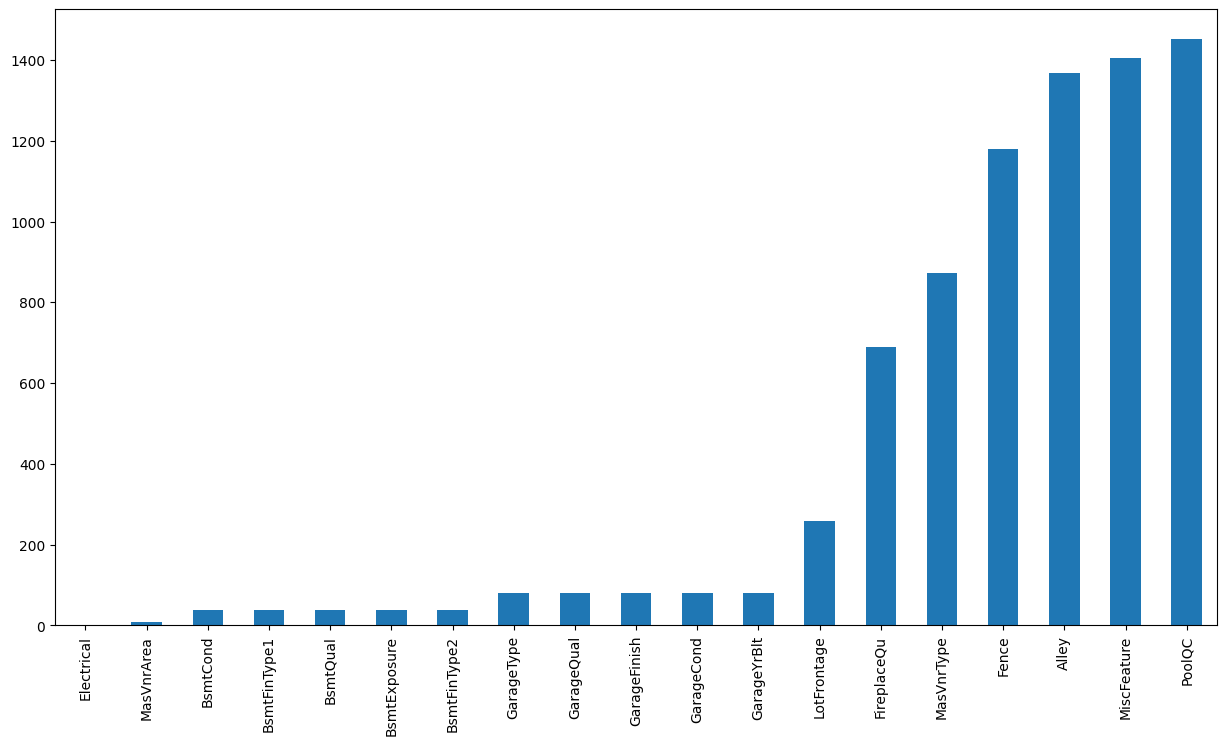

In [12]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
plt.figure(figsize=(15, 8))
missing.plot.bar()

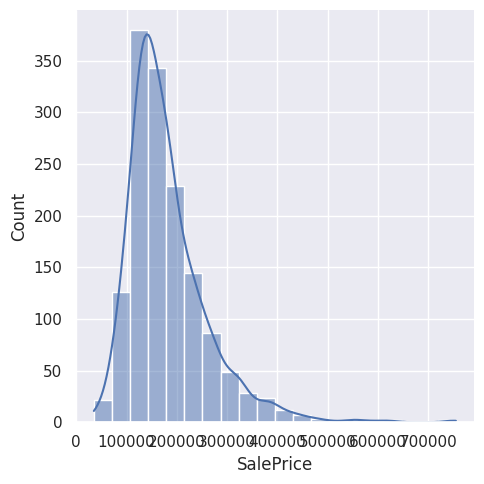

In [23]:
sns.set(rc={'figure.figsize':(15,8)})
sns.displot(df['SalePrice'],kde=True,  bins=20);

In [ ]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
Street,0
Alley,1369
LotShape,0
LandContour,0
Utilities,0


<Axes: >

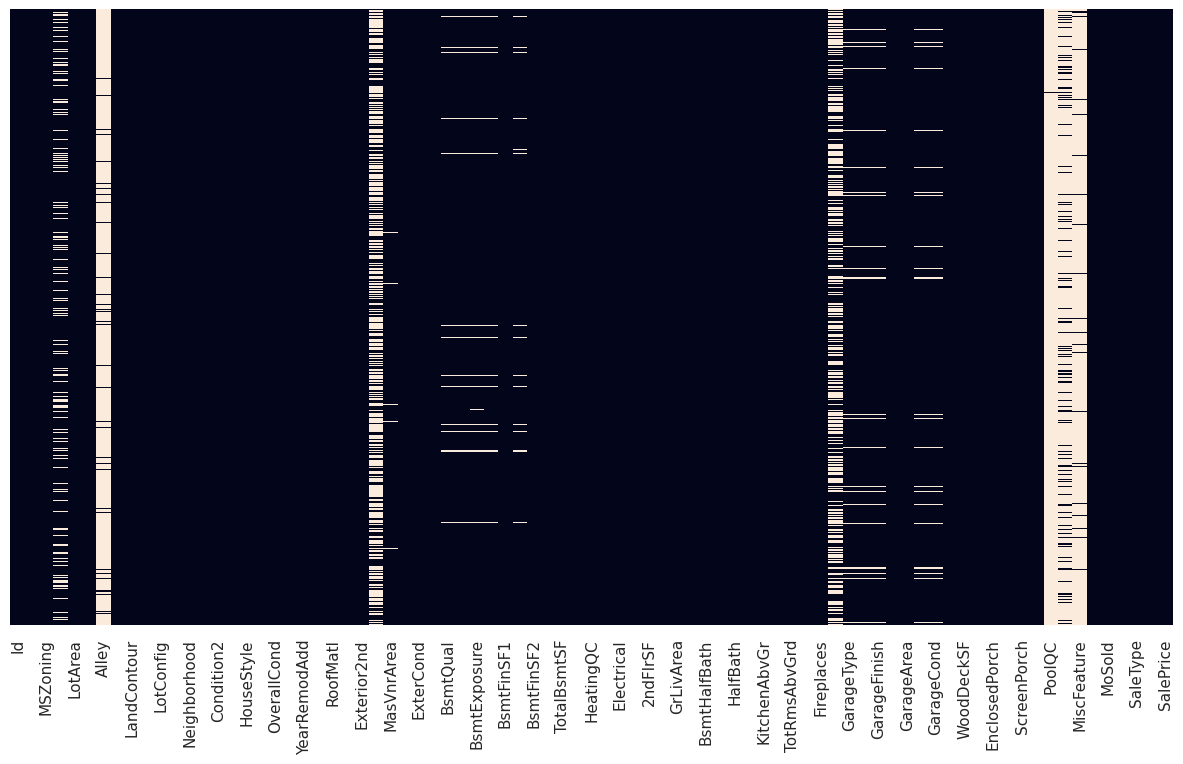

In [25]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [26]:
df.shape

(1460, 81)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [28]:
df.LotFrontage  = df.LotFrontage.fillna(df.LotFrontage.mean())

In [29]:
df.Alley.isnull().sum()

np.int64(1369)

In [30]:
df.Alley = df.drop(columns=['Alley'], inplace=True)

In [31]:
df.MSZoning.value_counts()

,count
MSZoning,
RL,1151
RM,218
FV,65
RH,16
C (all),10


In [32]:
df.MSZoning = df.MSZoning.fillna(df.MSZoning.mode()[0])
df.BsmtCond = df.BsmtCond.fillna(df.BsmtCond.mode()[0])
df.BsmtQual = df.BsmtQual.fillna(df.BsmtQual.mode()[0])
df.FireplaceQu = df.FireplaceQu.fillna(df.FireplaceQu.mode()[0])
df.GarageType = df.GarageType.fillna(df.GarageType.mode()[0])
df.GarageFinish = df.GarageFinish.fillna(df.GarageFinish.mode()[0])
df.GarageQual = df.GarageQual.fillna(df.GarageQual.mode()[0])
df.GarageCond = df.GarageCond.fillna(df.GarageCond.mode()[0])
df.drop(columns=['GarageYrBlt'], axis=1, inplace=True)
df.drop(columns=['PoolQC', 'Fence', 'MiscFeature'], axis=1, inplace=True)

In [33]:
df.shape

(1460, 76)

In [34]:
df.drop(columns=['Id'], axis=1, inplace=True)

In [35]:
df.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
LotShape,0
LandContour,0
Utilities,0
LotConfig,0
LandSlope,0


In [36]:
df.MasVnrArea = df.MasVnrArea.fillna(df.MasVnrArea.mode()[0])
df.MasVnrType = df.MasVnrType.fillna(df.MasVnrType.mode()[0])

<Axes: >

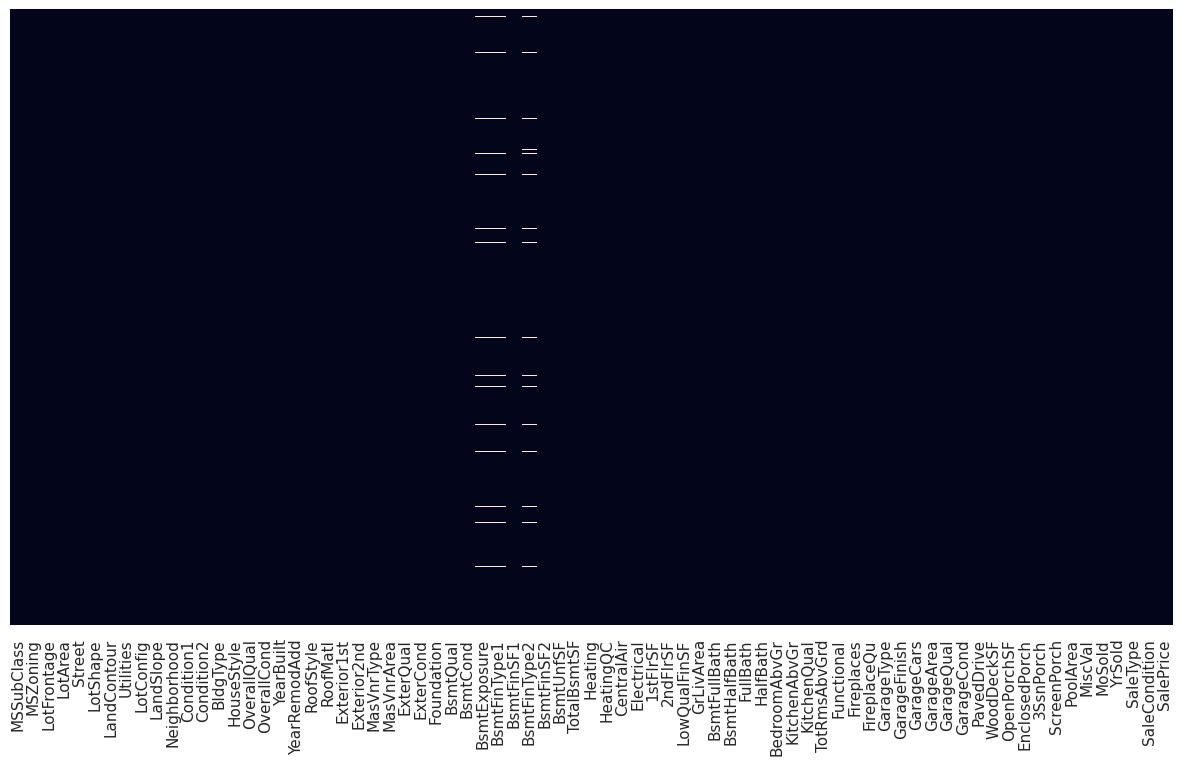

In [37]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [38]:
df.BsmtExposure = df.BsmtExposure.fillna(df.BsmtExposure.mode()[0])
df.BsmtFinType1 = df.BsmtFinType1.fillna(df.BsmtFinType1.mode()[0])
df.BsmtFinType2 = df.BsmtFinType2.fillna(df.BsmtFinType2.mode()[0])

<Axes: >

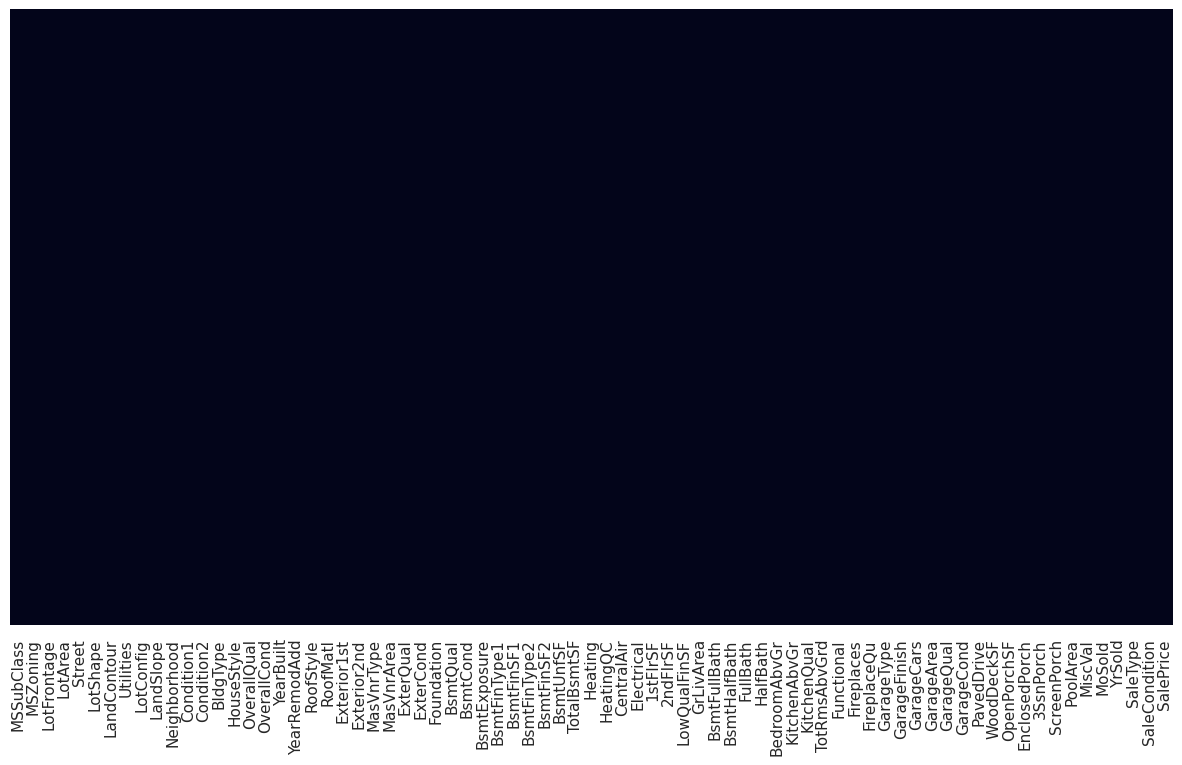

In [39]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [40]:
df.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
LotShape,0
LandContour,0
Utilities,0
LotConfig,0
LandSlope,0


In [41]:
df.dropna(inplace=True)

In [42]:
df.shape

(1459, 75)

In [43]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Gd,Attchd,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,BrkFace,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,BrkFace,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000


### 1.2	Converting Categorical Variables: Encode categorical variables using suitable methods (e.g., one-hot encoding).

In [44]:
categorical_features = df.select_dtypes(include='object').columns
categorical_features

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [45]:
len(categorical_features)

39

In [46]:
main_df = df.copy()
main_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Gd,Attchd,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,BrkFace,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,BrkFace,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000


In [47]:
main_df.shape

(1459, 75)

In [48]:
df.shape

(1459, 75)

In [49]:
final_df = main_df
final_df.shape

(1459, 75)

In [50]:
def category_onehot_multcols(multcolumns):
    df_final=final_df
    i=0
    for fields in multcolumns:


        df1=pd.get_dummies(final_df[fields],drop_first=True)

        final_df.drop([fields],axis=1,inplace=True)
        if i==0:
            df_final=df1.copy()
        else:

            df_final=pd.concat([df_final,df1],axis=1)
        i=i+1


    df_final=pd.concat([final_df,df_final],axis=1)

    return df_final

In [51]:
final_df=category_onehot_multcols(categorical_features)

In [52]:
final_df = final_df.loc[:,~final_df.columns.duplicated()]
print(f"Shape after removing duplicates: {final_df.shape}")

Shape after removing duplicates: (1459, 175)


In [53]:
final_df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,FV,RH,RL,RM,Pave,IR2,IR3,Reg,HLS,Low,Lvl,NoSeWa,CulDSac,FR2,FR3,Inside,Mod,Sev,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,MeadowV,Mitchel,NAmes,NPkVill,NWAmes,NoRidge,NridgHt,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker,Feedr,Norm,PosA,PosN,RRAe,RRAn,RRNe,RRNn,2fmCon,Duplex,Twnhs,TwnhsE,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl,Gable,Gambrel,Hip,Mansard,Shed,CompShg,Membran,Metal,Roll,Tar&Grv,WdShake,WdShngl,AsphShn,BrkComm,BrkFace,CBlock,CemntBd,HdBoard,ImStucc,MetalSd,Plywood,Stone,Stucco,VinylSd,Wd Sdng,WdShing,Brk Cmn,CmentBd,Other,Wd Shng,Fa,Gd,TA,Po,PConc,Slab,Wood,Mn,No,BLQ,GLQ,LwQ,Rec,Unf,GasA,GasW,Grav,OthW,Wall,Y,FuseF,FuseP,Mix,SBrkr,Maj2,Min1,Min2,Typ,Attchd,Basment,BuiltIn,CarPort,Detchd,RFn,P,CWD,Con,ConLD,ConLI,ConLw,New,Oth,WD,AdjLand,Alloca,Family,Normal,Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2,548,0,61,0,0,0,0,0,2,2008,208500,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,2,460,298,0,0,0,0,0,0,5,2007,181500,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2,608,0,42,0,0,0,0,0,9,2008,223500,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,T

### 1.3	Normalising Numerical Features: Normalise numerical features to ensure they are on a comparable scale

In [54]:
# Identify numerical columns
numerical_features = final_df.select_dtypes(include=np.number).columns.tolist()

# Exclude the target variable 'SalePrice' if it's in the numerical features
if 'SalePrice' in numerical_features:
    numerical_features.remove('SalePrice')

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical features of the final_df
final_df[numerical_features] = scaler.fit_transform(final_df[numerical_features])

final_df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,FV,RH,RL,RM,Pave,IR2,IR3,Reg,HLS,Low,Lvl,NoSeWa,CulDSac,FR2,FR3,Inside,Mod,Sev,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,MeadowV,Mitchel,NAmes,NPkVill,NWAmes,NoRidge,NridgHt,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker,Feedr,Norm,PosA,PosN,RRAe,RRAn,RRNe,RRNn,2fmCon,Duplex,Twnhs,TwnhsE,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl,Gable,Gambrel,Hip,Mansard,Shed,CompShg,Membran,Metal,Roll,Tar&Grv,WdShake,WdShngl,AsphShn,BrkComm,BrkFace,CBlock,CemntBd,HdBoard,ImStucc,MetalSd,Plywood,Stone,Stucco,VinylSd,Wd Sdng,WdShing,Brk Cmn,CmentBd,Other,Wd Shng,Fa,Gd,TA,Po,PConc,Slab,Wood,Mn,No,BLQ,GLQ,LwQ,Rec,Unf,GasA,GasW,Grav,OthW,Wall,Y,FuseF,FuseP,Mix,SBrkr,Maj2,Min1,Min2,Typ,Attchd,Basment,BuiltIn,CarPort,Detchd,RFn,P,CWD,Con,ConLD,ConLI,ConLw,New,Oth,WD,AdjLand,Alloca,Family,Normal,Partial
0,0.073732,-0.229203,-0.207125,0.650852,-0.517424,1.051899,0.879449,0.513594,0.574748,-0.28876,-0.944607,-0.460570,-0.794191,1.162093,-0.120284,0.370055,1.107124,-0.241148,0.790180,1.228641,0.163837,-0.211529,0.912128,-0.951848,0.311842,0.350660,-0.751887,0.215983,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,-1.599030,0.138826,208500,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
1,-0.871979,0.451876,-0.091909,-0.072372,2.178727,0.157540,-0.428864,-0.571009,1.171304,-0.28876,-0.641330,0.465629,0.256426,-0.794554,-0.120284,-0.482514,-0.820434,3.947370,0.790180,-0.760912,0.163837,-0.211529,-0.318380,0.599824,0.311842,-0.060947,1.625670,-0.704845,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,-0.489318,-0.614137,181500,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
2,0.073732,-0.092987,0.073401,0.650852,-0.517424,0.985650,0.830993,0.325449,0.092239,-0.28876,-0.301842,-0.314568,-0.628576,1.189587,-0.120284,0.514687,1.107124,-0.241148,0.790180,1.228641,0.163837,-0.211529,-0.318380,0.599824,0.311842,0.631301,-0.751887,-0.070832,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,0.990298,0.138826,223500,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,F

### 1.4	Outlier Detection: Identify and handle outliers in the dataset.

<Axes: xlabel='SalePrice'>

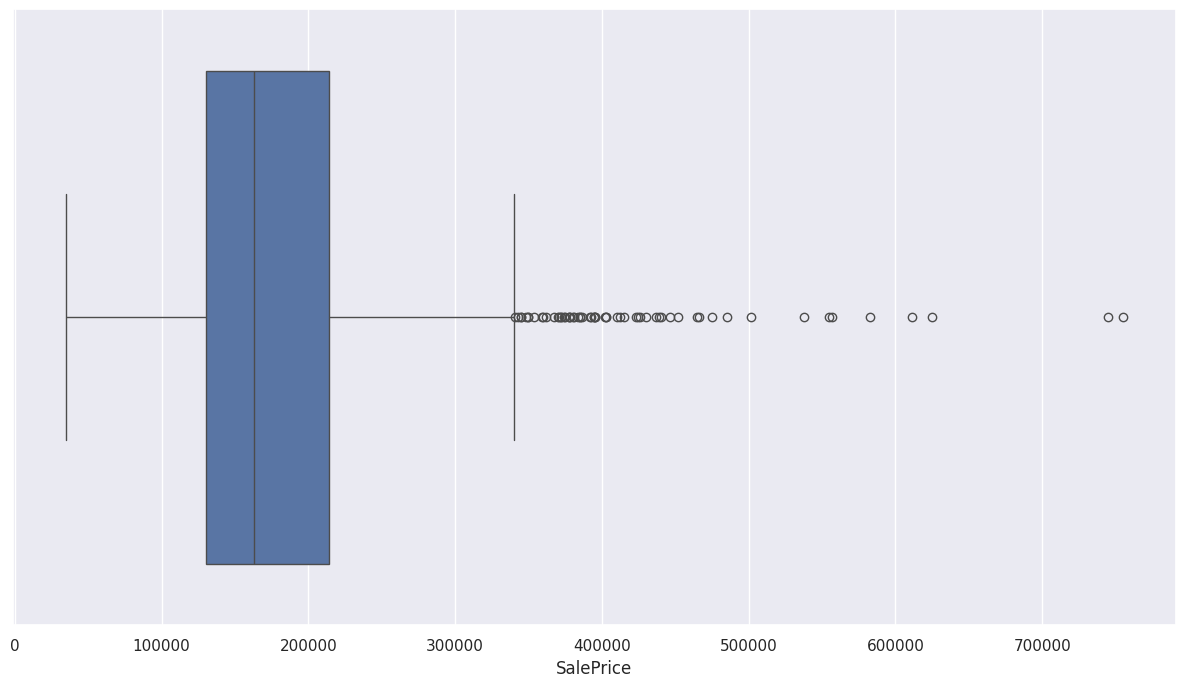

In [56]:
sns.boxplot(x=final_df['SalePrice'])

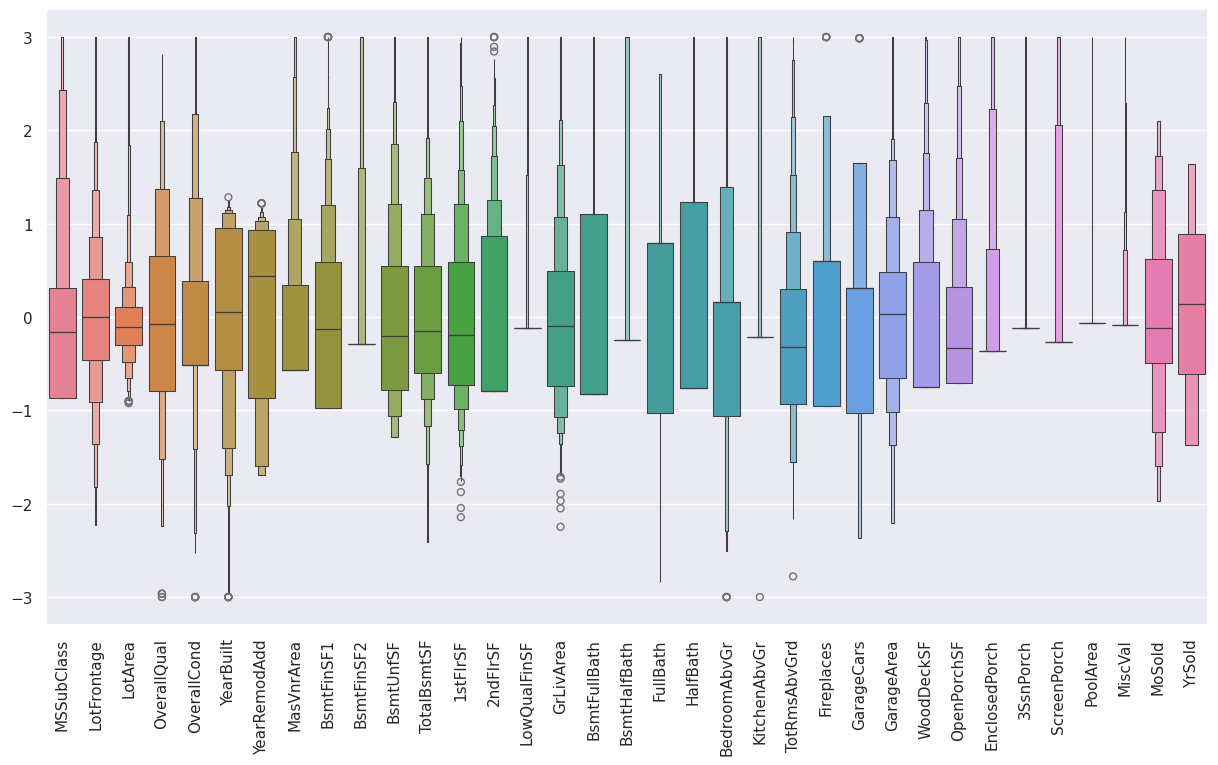

In [64]:
sns.boxenplot(data=final_df[numerical_features])
plt.xticks(rotation=90)
plt.show()

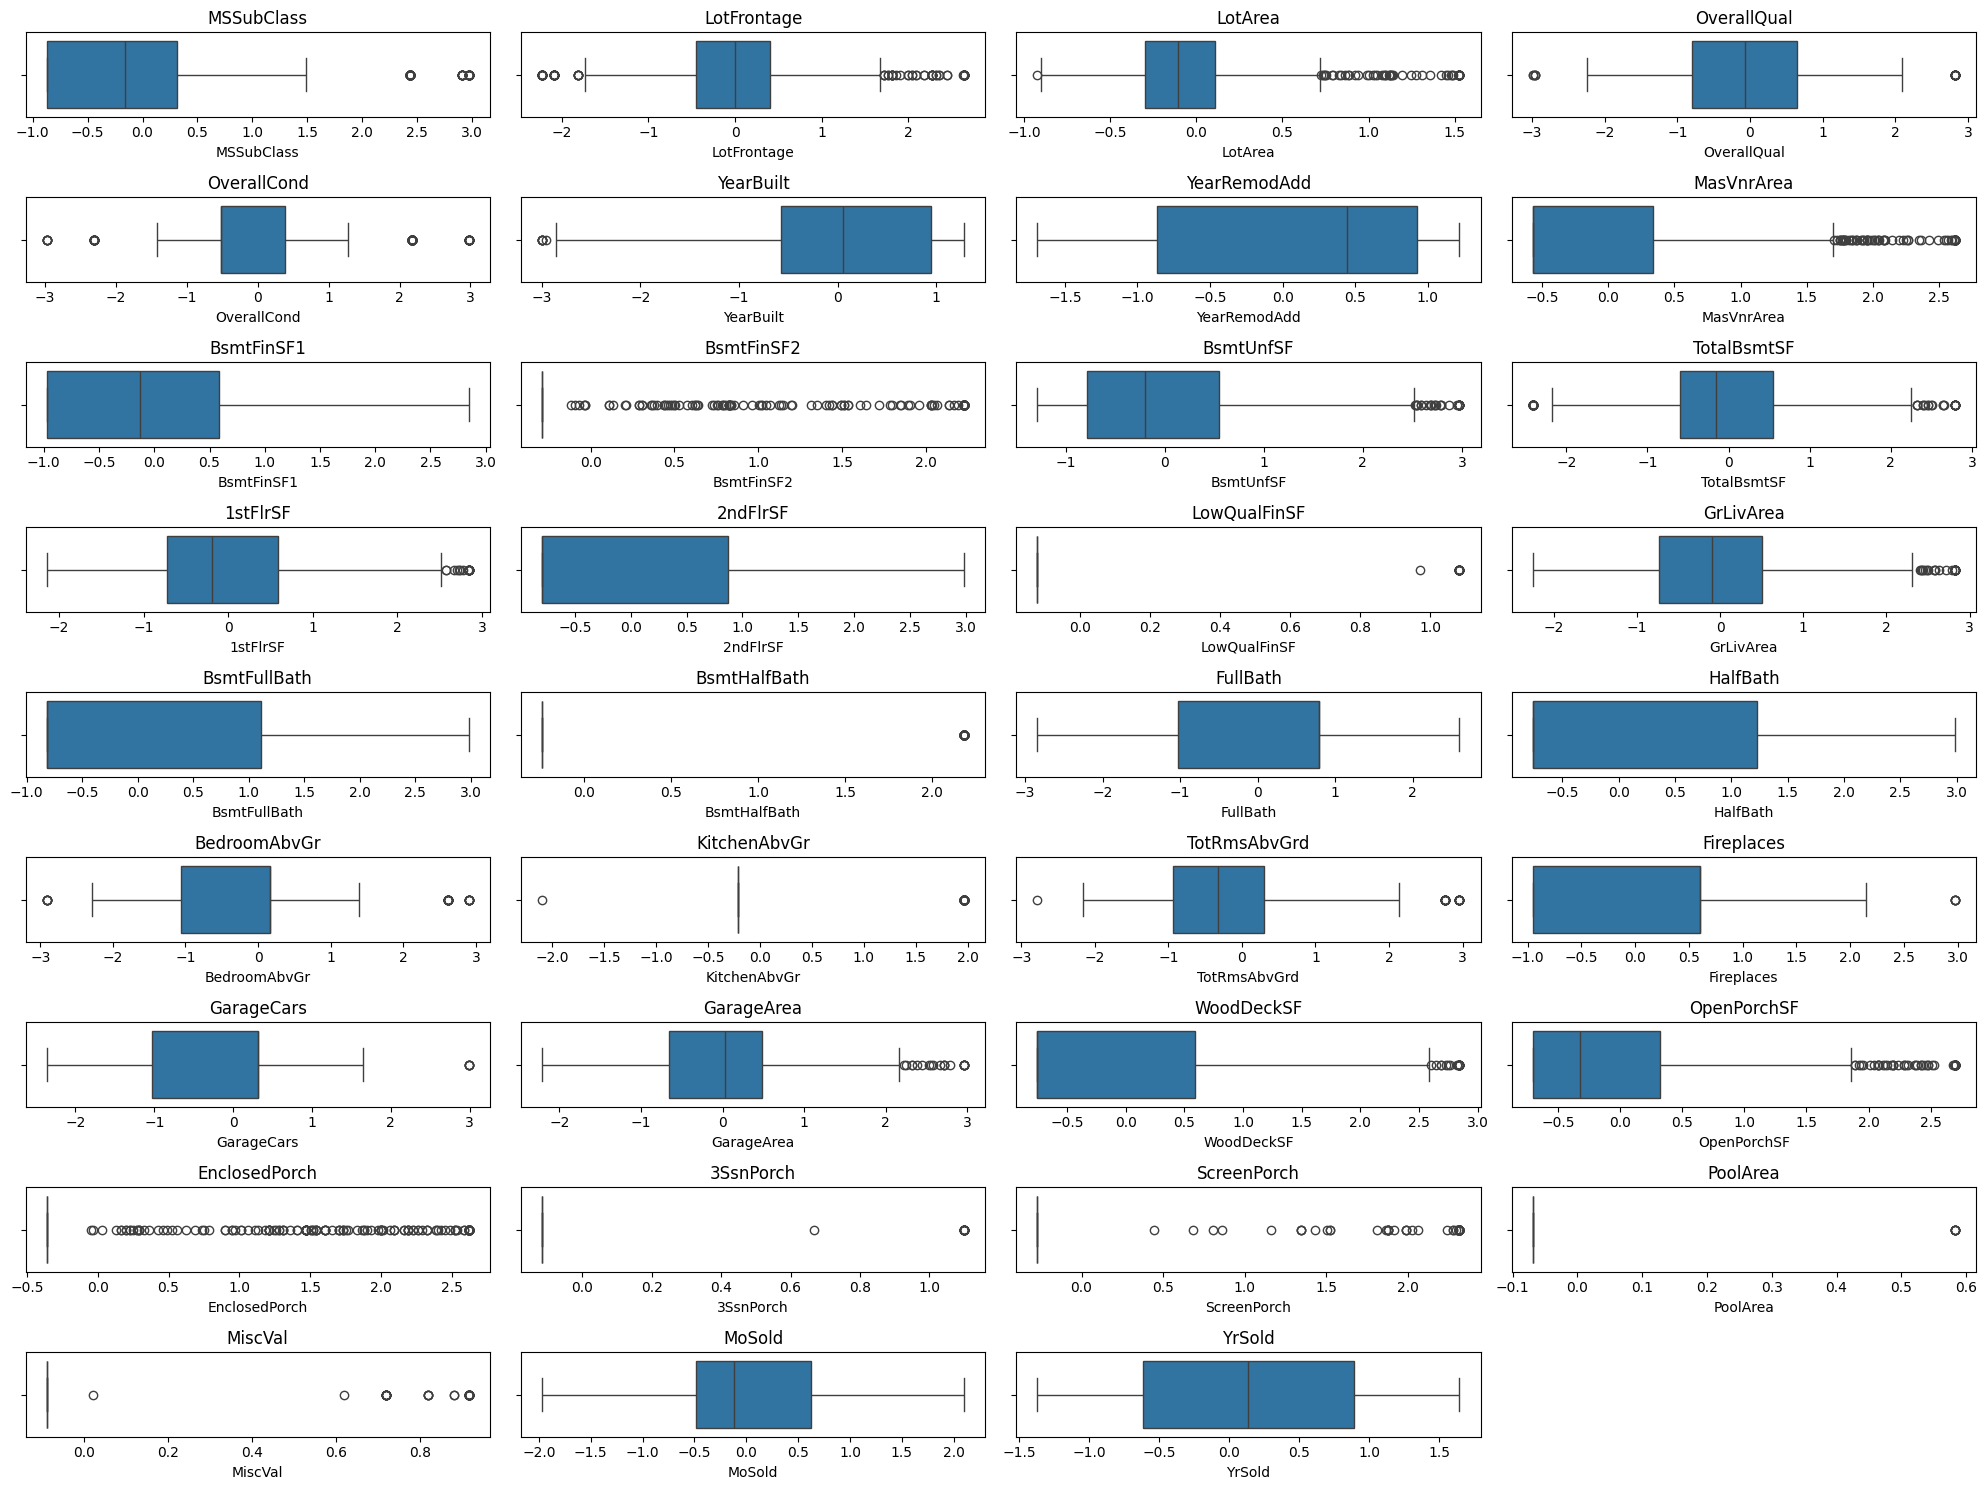

In [ ]:
import math
# prompt: how to see ouliers in dataset final_df for all numerical features using plot?

# Identify numerical columns again, as they might have been normalized
numerical_features_for_plot = final_df.select_dtypes(include=np.number).columns.tolist()

# Exclude the target variable 'SalePrice' if it's in the numerical features
if 'SalePrice' in numerical_features_for_plot:
    numerical_features_for_plot.remove('SalePrice')

# Plot boxplots for each numerical feature to visualize outliers
plt.figure(figsize=(20, 15)) # Adjust figure size as needed

for i, col in enumerate(numerical_features_for_plot):
    plt.subplot(math.ceil(len(numerical_features_for_plot)/4), 4, i + 1) # Create subplots
    sns.boxplot(x=final_df[col])
    plt.title(col)

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

Column: MSSubClass
Shapiro-Wilk Statistic: 0.8043, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


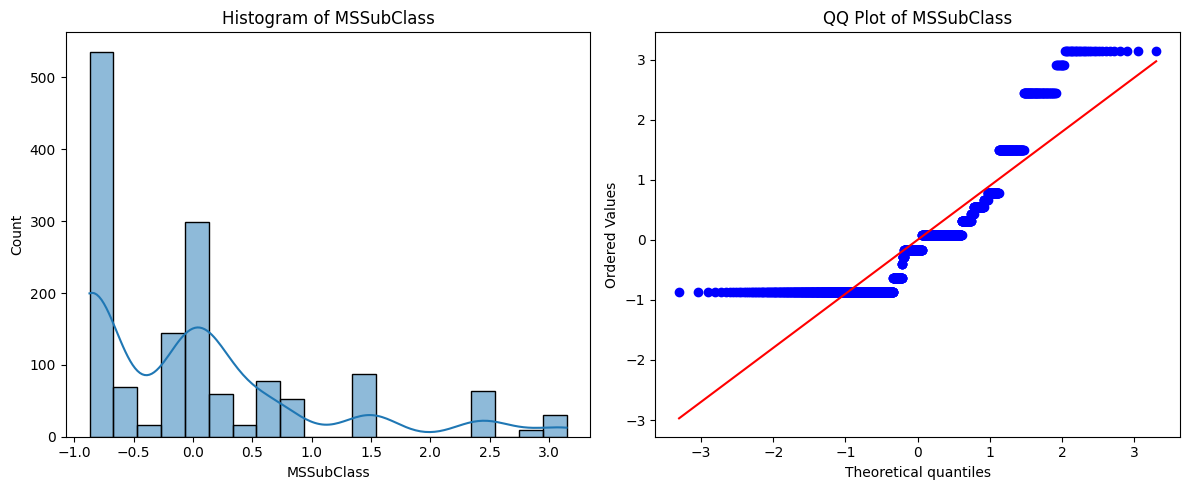

Column: LotFrontage
Shapiro-Wilk Statistic: 0.8507, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


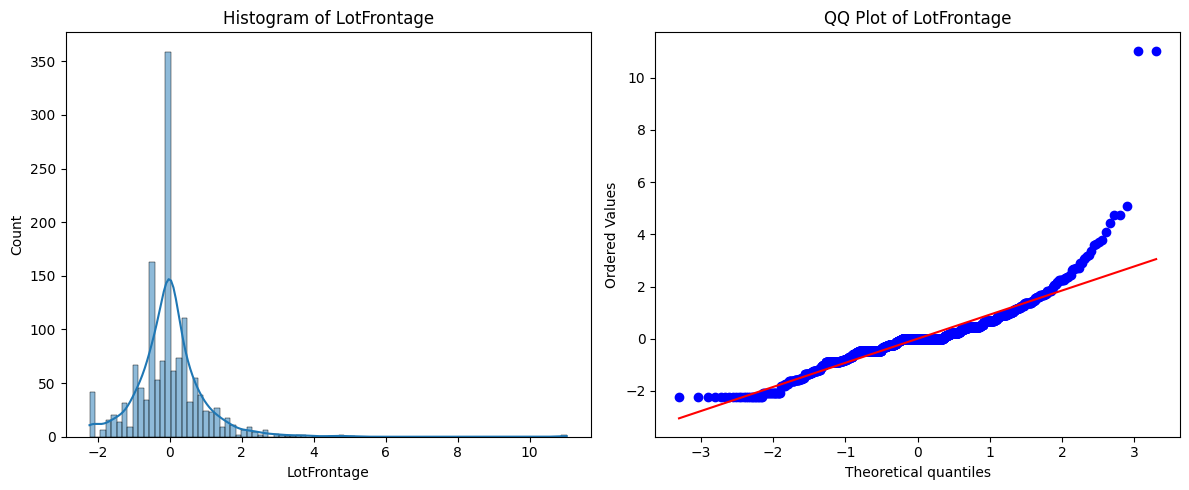

Column: LotArea
Shapiro-Wilk Statistic: 0.3511, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


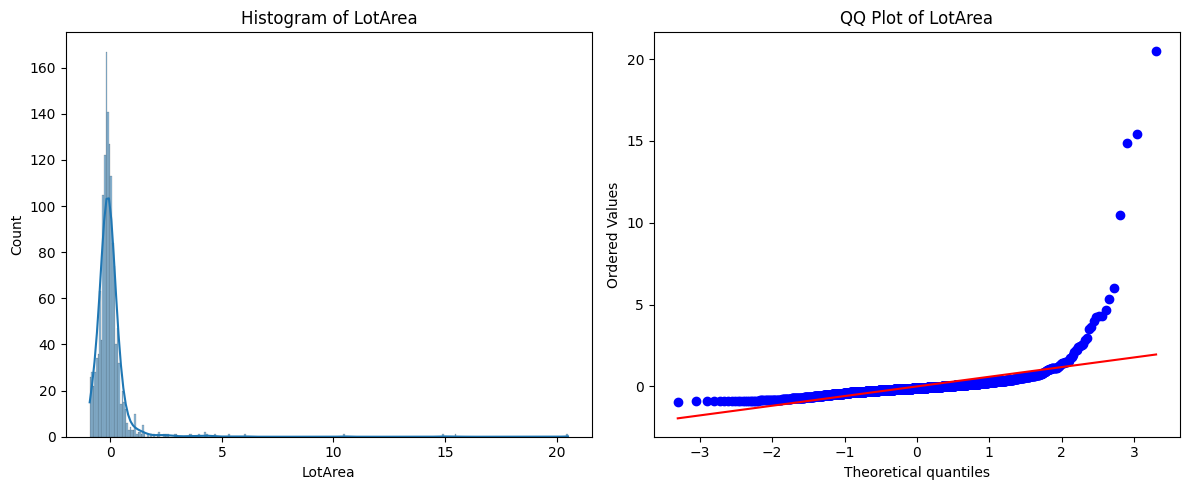

Column: OverallQual
Shapiro-Wilk Statistic: 0.9481, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


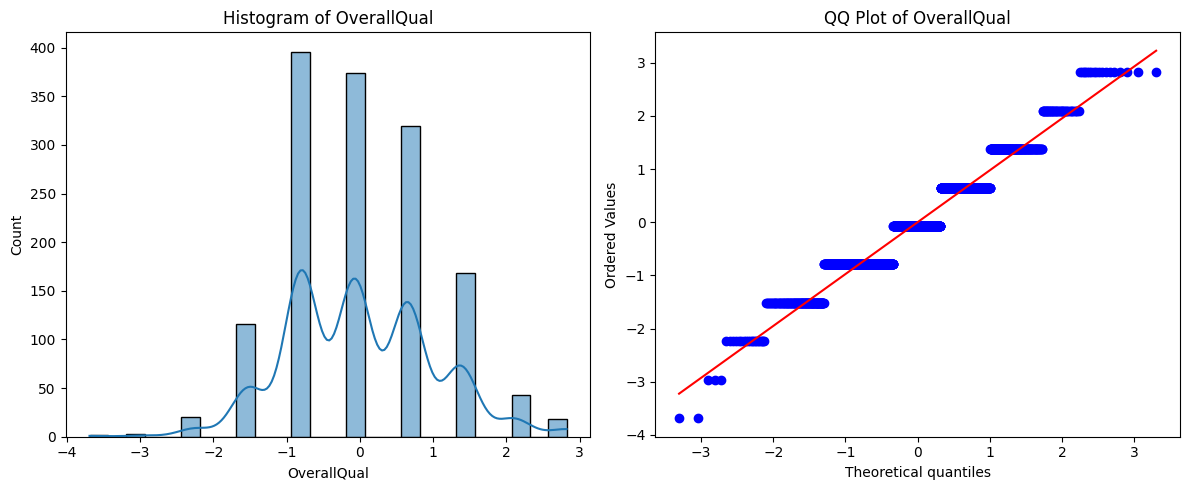

Column: OverallCond
Shapiro-Wilk Statistic: 0.8291, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


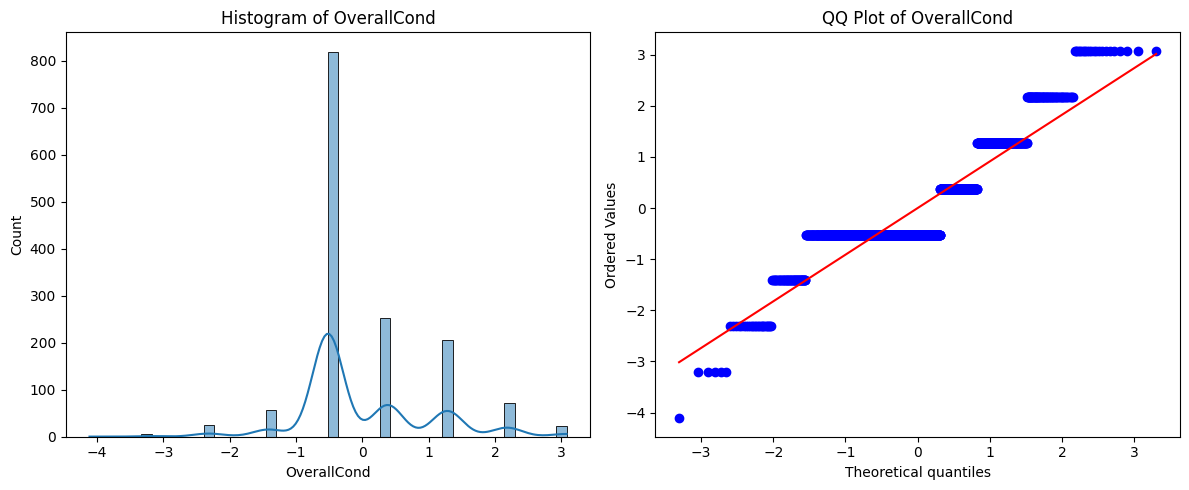

Column: YearBuilt
Shapiro-Wilk Statistic: 0.9258, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


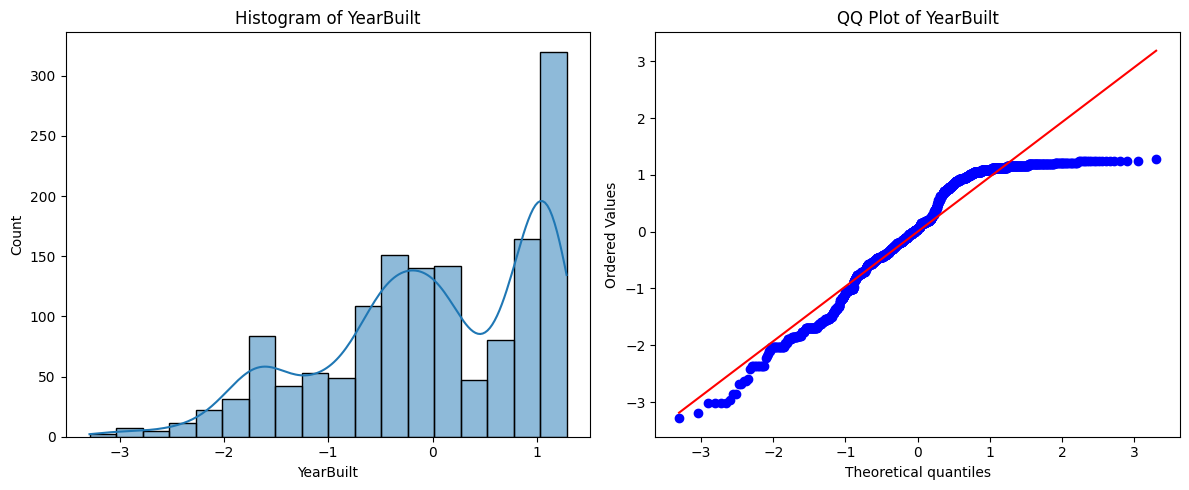

Column: YearRemodAdd
Shapiro-Wilk Statistic: 0.8629, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


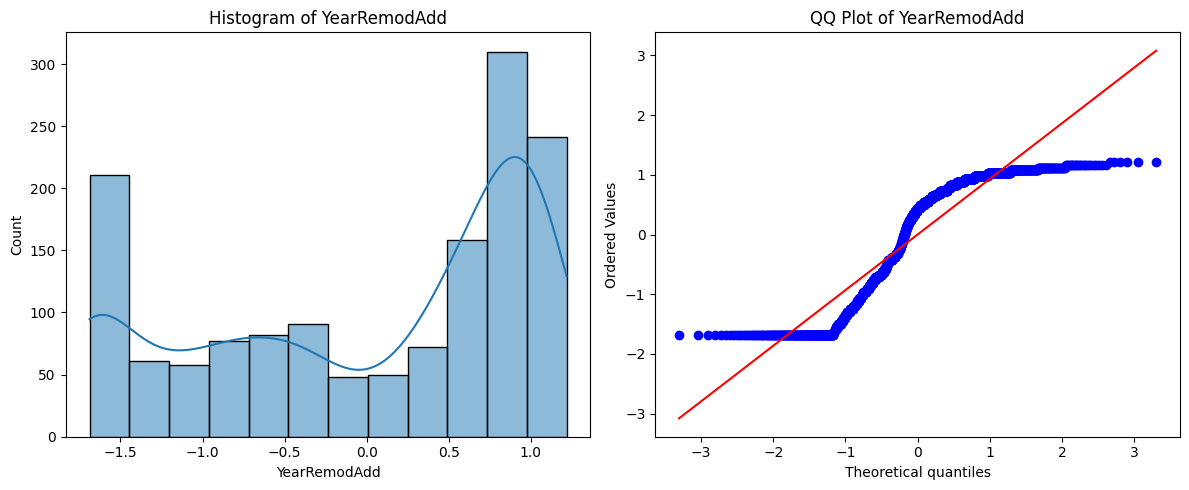

Column: MasVnrArea
Shapiro-Wilk Statistic: 0.6378, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


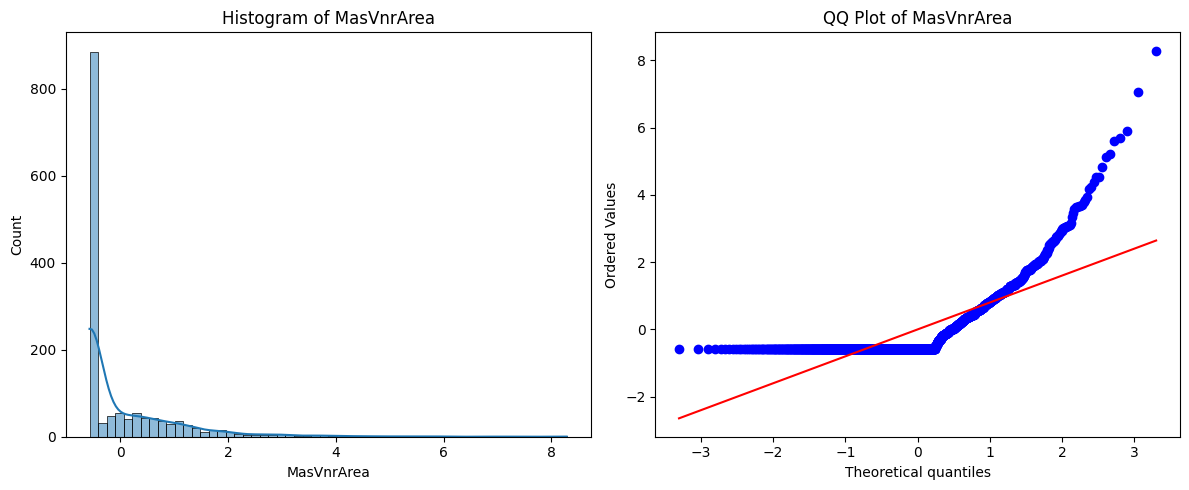

Column: BsmtFinSF1
Shapiro-Wilk Statistic: 0.8481, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


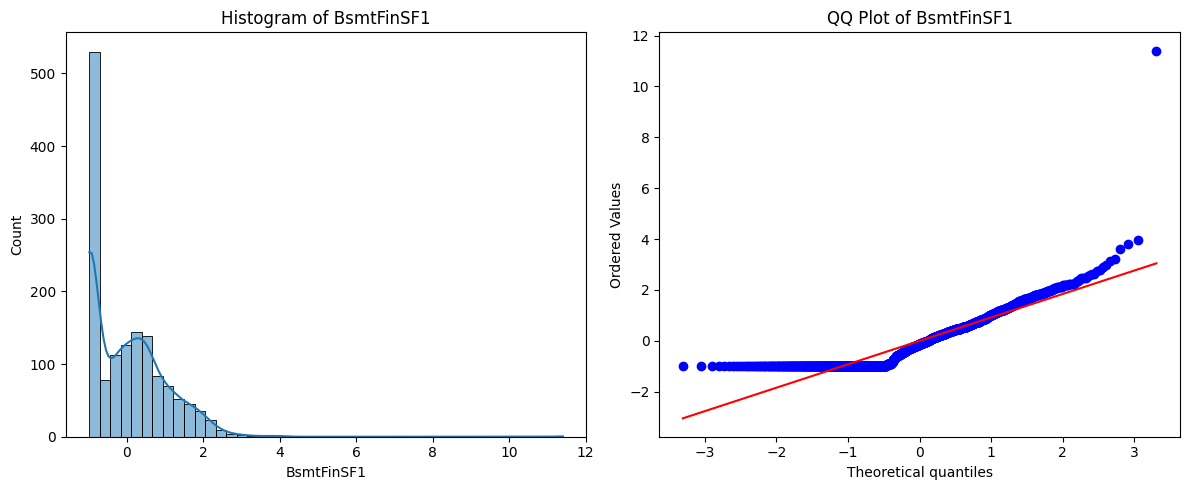

Column: BsmtFinSF2
Shapiro-Wilk Statistic: 0.3274, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


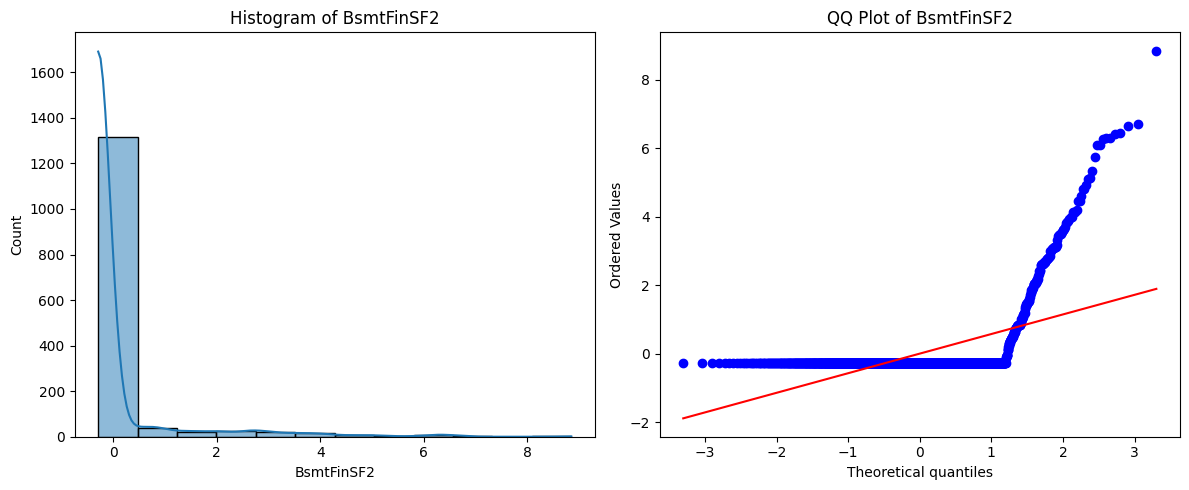

Column: BsmtUnfSF
Shapiro-Wilk Statistic: 0.9305, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


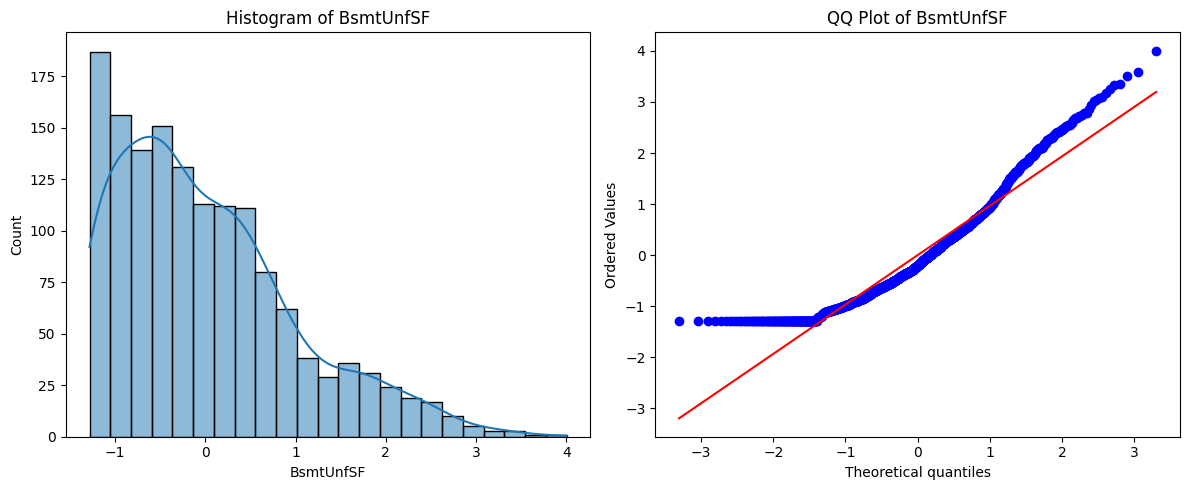

Column: TotalBsmtSF
Shapiro-Wilk Statistic: 0.9170, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


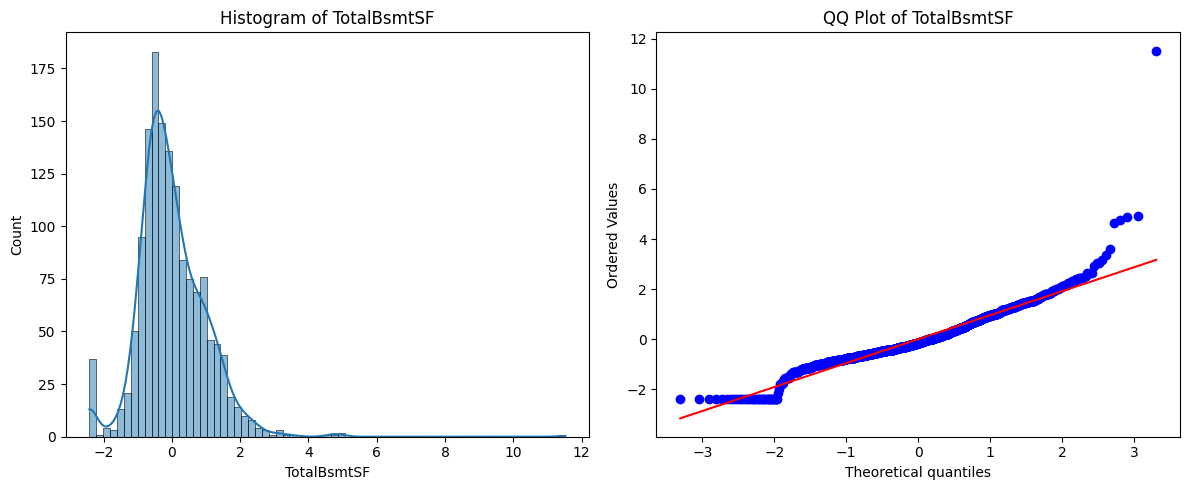

Column: 1stFlrSF
Shapiro-Wilk Statistic: 0.9270, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


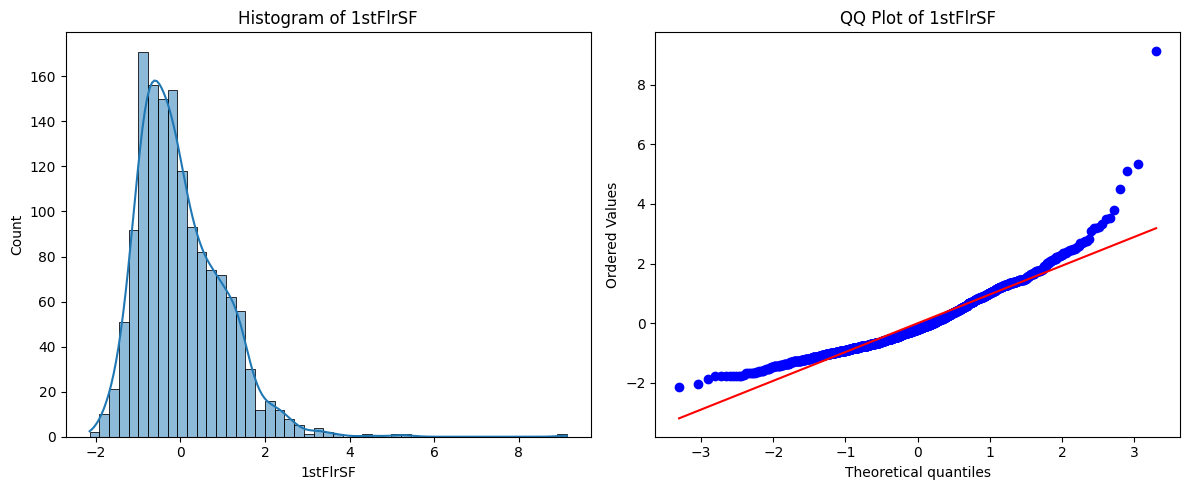

Column: 2ndFlrSF
Shapiro-Wilk Statistic: 0.7665, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


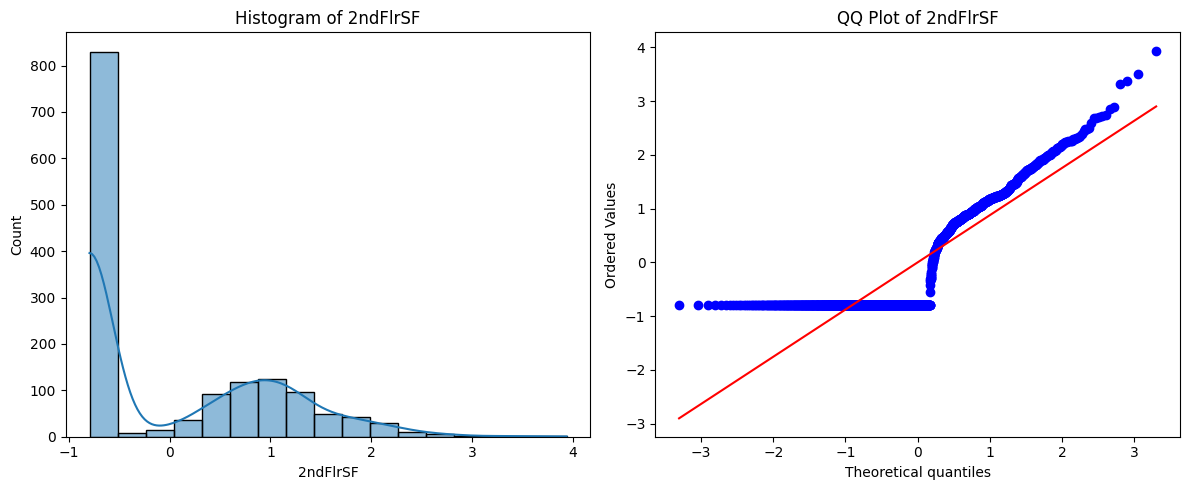

Column: LowQualFinSF
Shapiro-Wilk Statistic: 0.0980, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


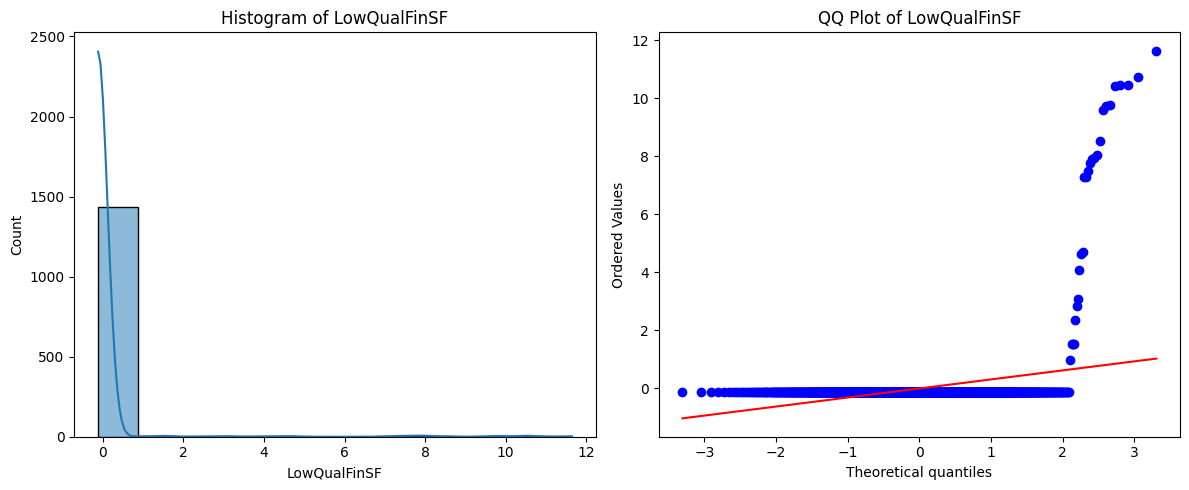

Column: GrLivArea
Shapiro-Wilk Statistic: 0.9280, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


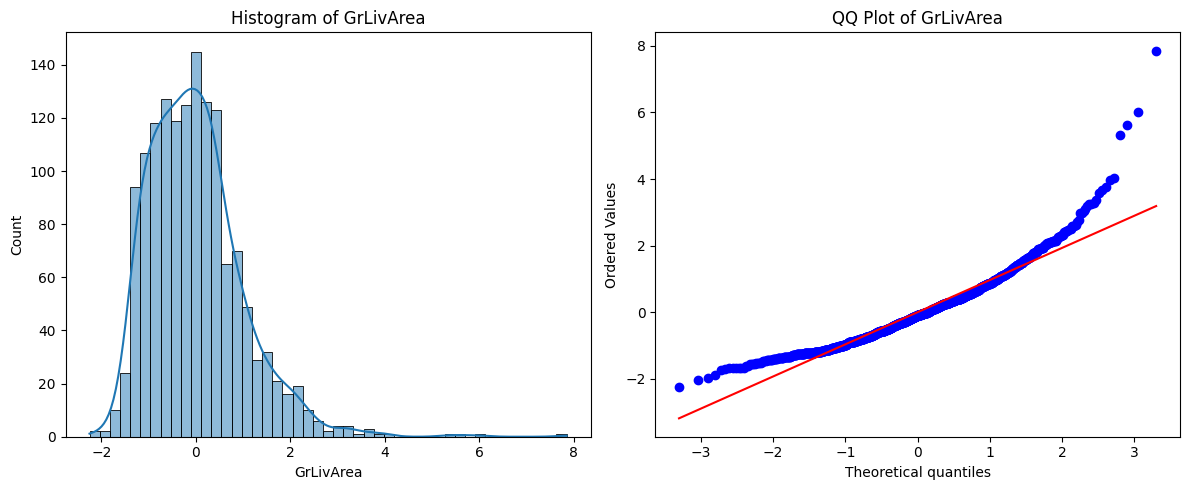

Column: BsmtFullBath
Shapiro-Wilk Statistic: 0.6584, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


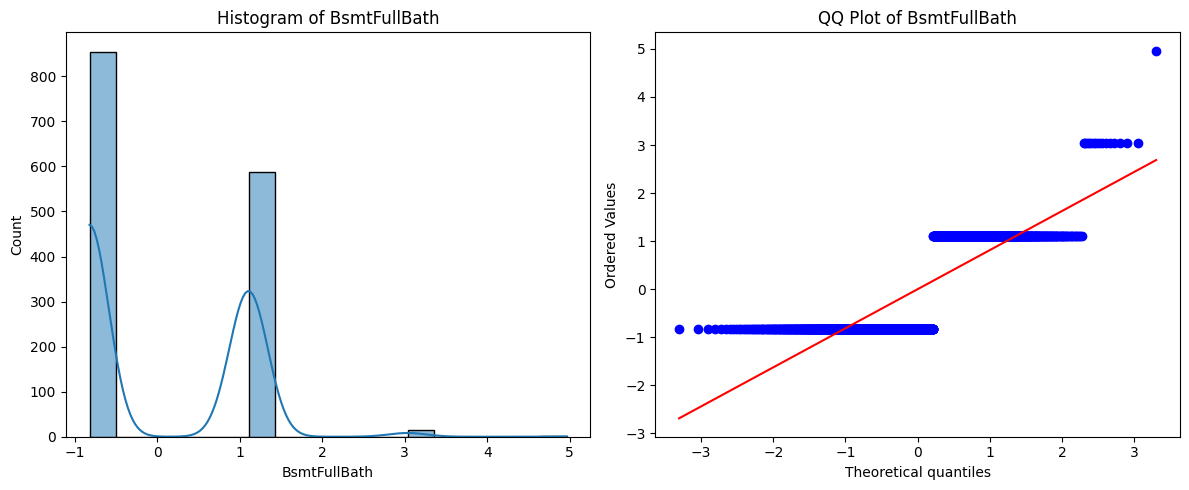

Column: BsmtHalfBath
Shapiro-Wilk Statistic: 0.2430, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


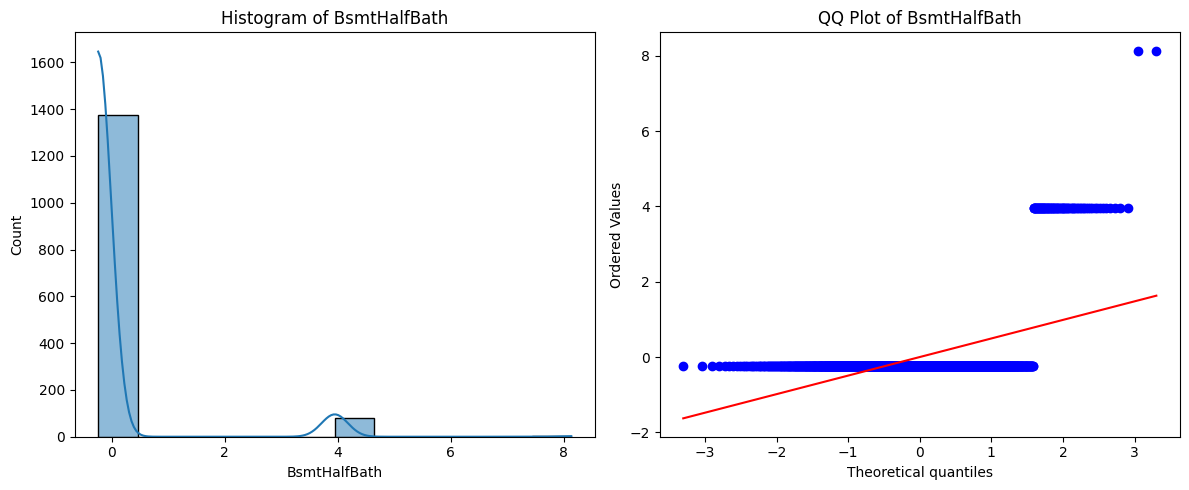

Column: FullBath
Shapiro-Wilk Statistic: 0.7194, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


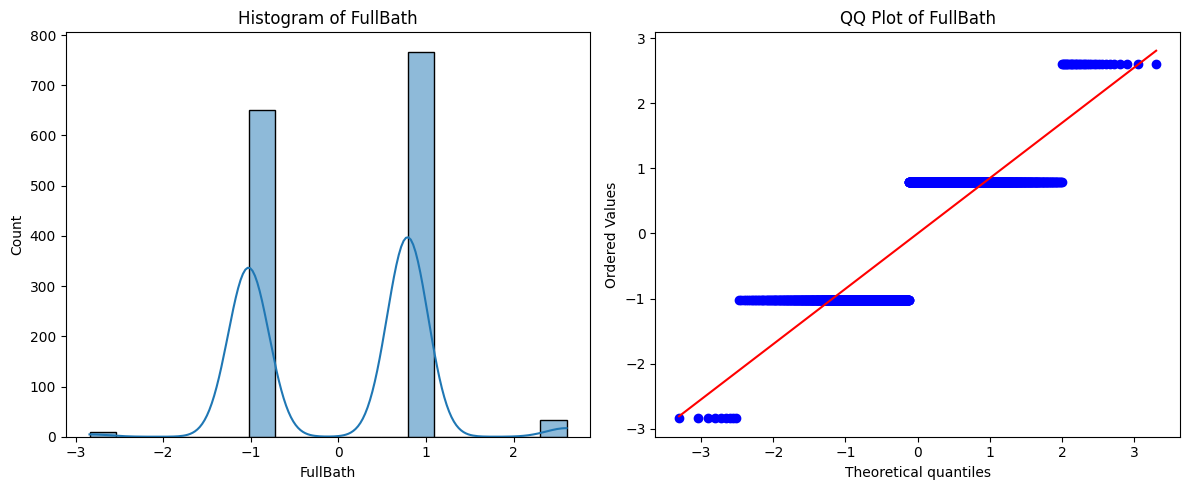

Column: HalfBath
Shapiro-Wilk Statistic: 0.6378, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


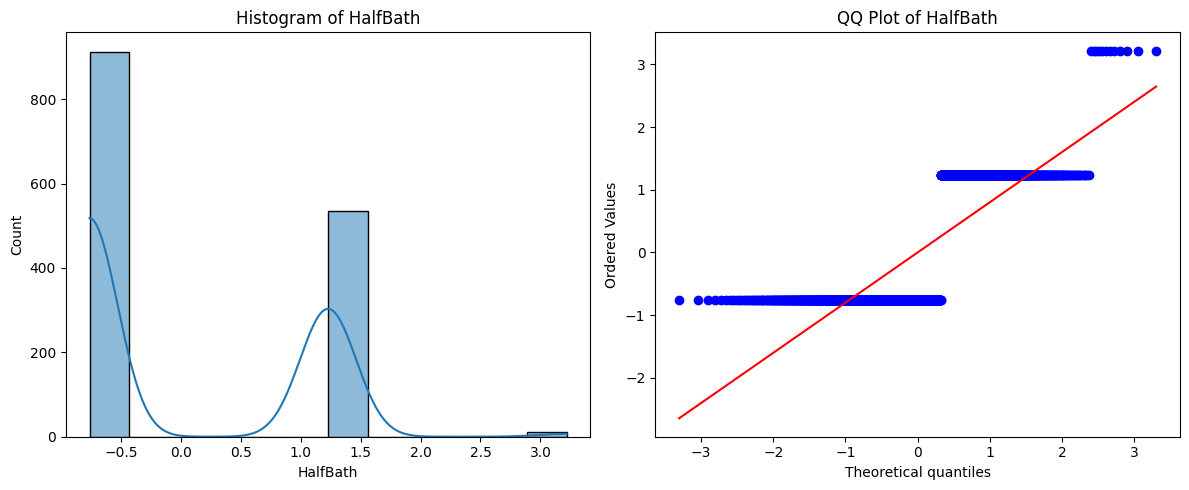

Column: BedroomAbvGr
Shapiro-Wilk Statistic: 0.8500, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


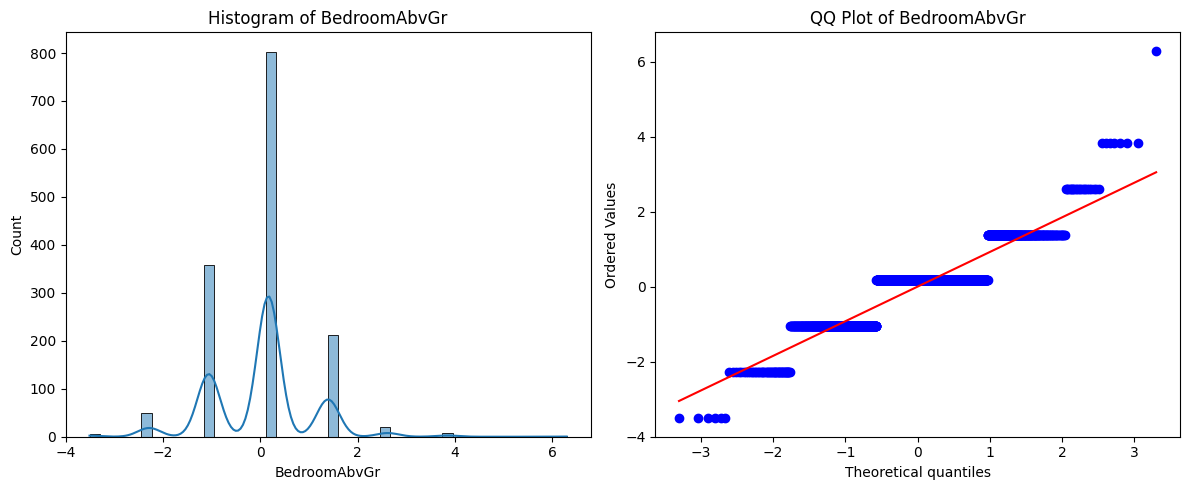

Column: KitchenAbvGr
Shapiro-Wilk Statistic: 0.2199, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


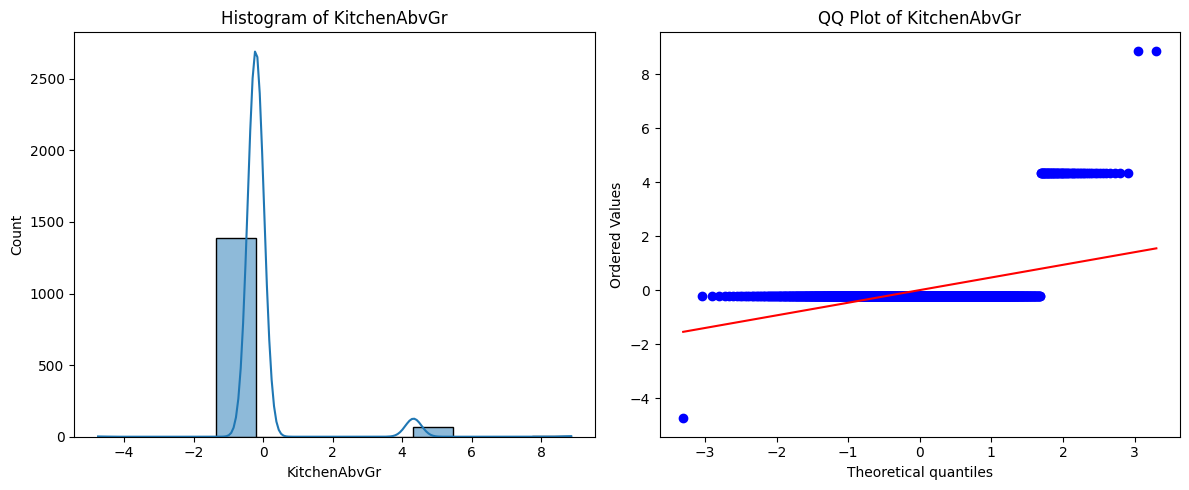

Column: TotRmsAbvGrd
Shapiro-Wilk Statistic: 0.9423, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


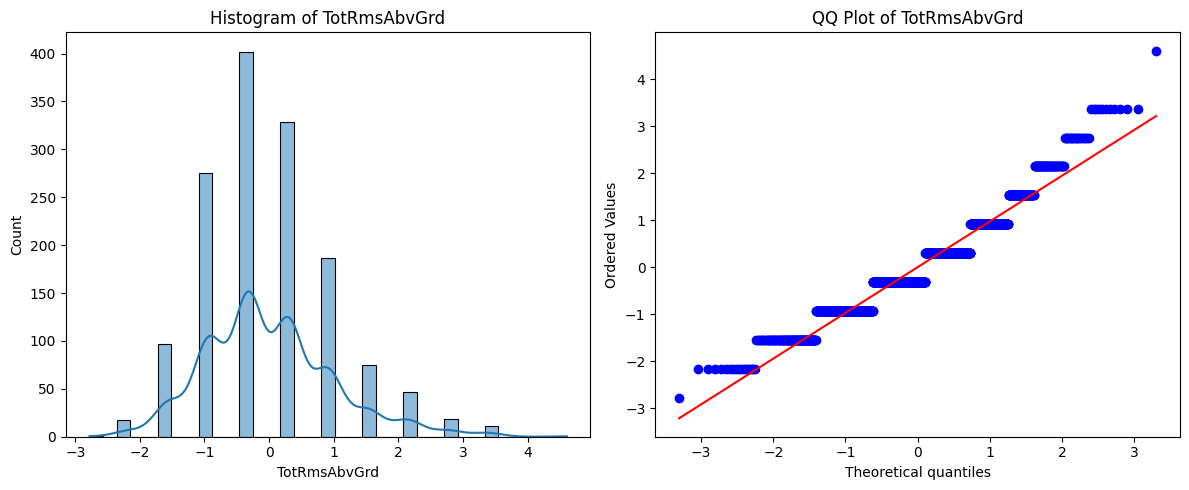

Column: Fireplaces
Shapiro-Wilk Statistic: 0.7553, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


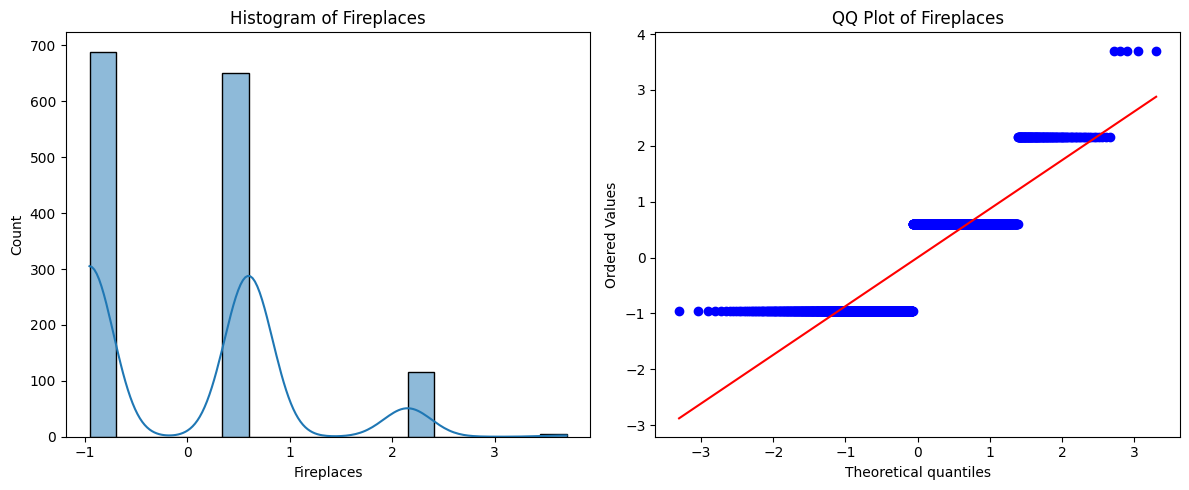

Column: GarageCars
Shapiro-Wilk Statistic: 0.8355, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


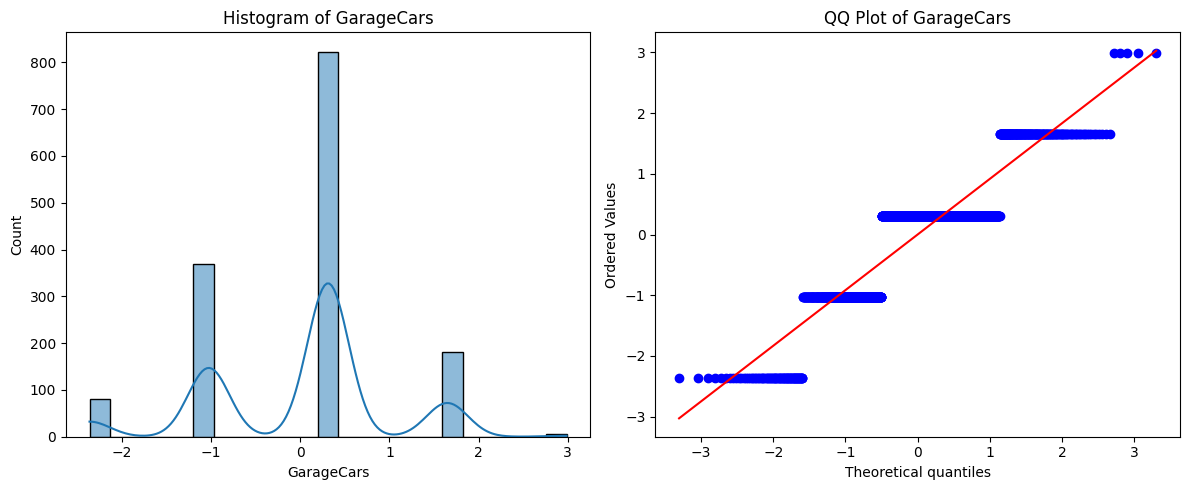

Column: GarageArea
Shapiro-Wilk Statistic: 0.9753, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


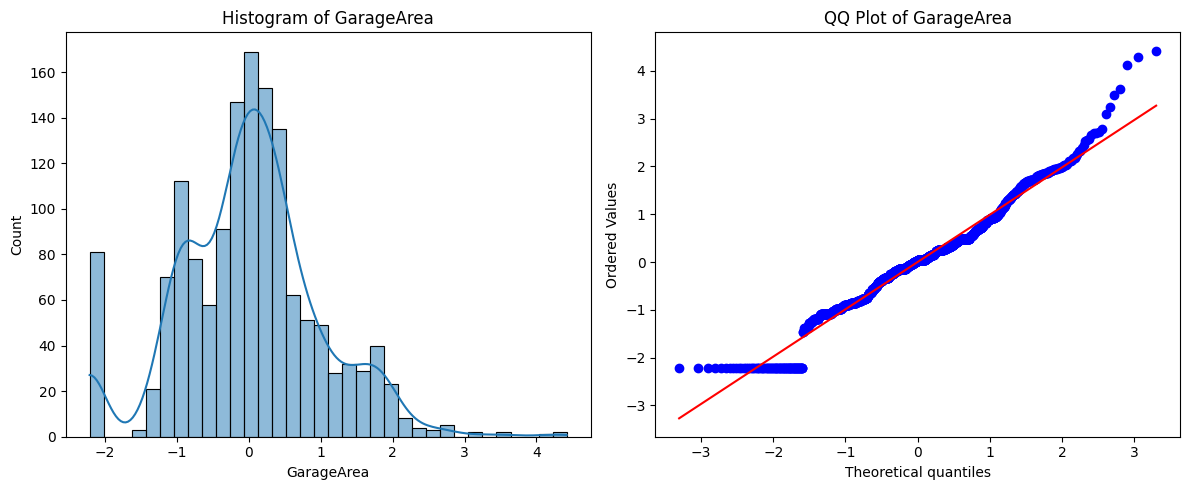

Column: WoodDeckSF
Shapiro-Wilk Statistic: 0.7683, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


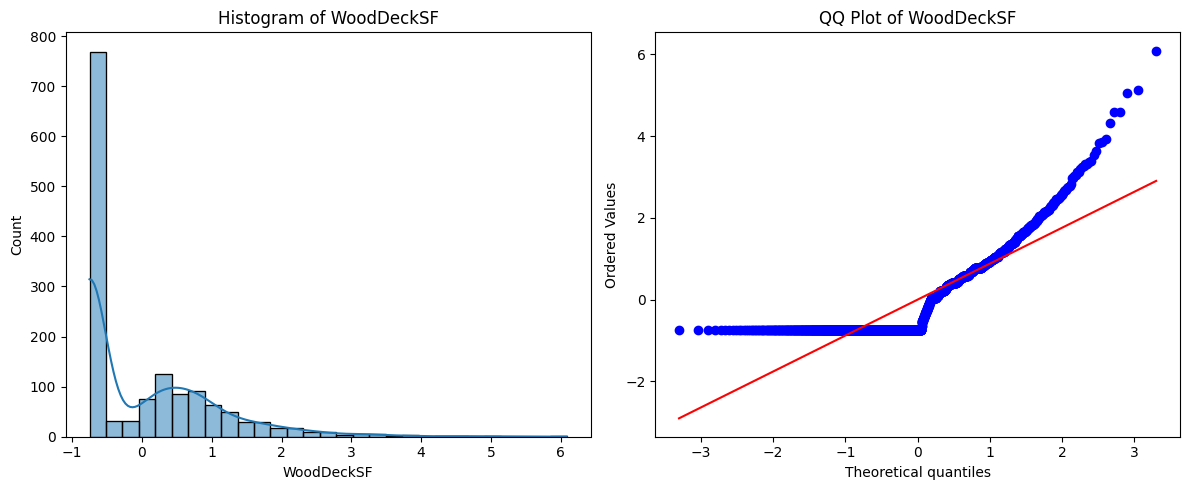

Column: OpenPorchSF
Shapiro-Wilk Statistic: 0.7274, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


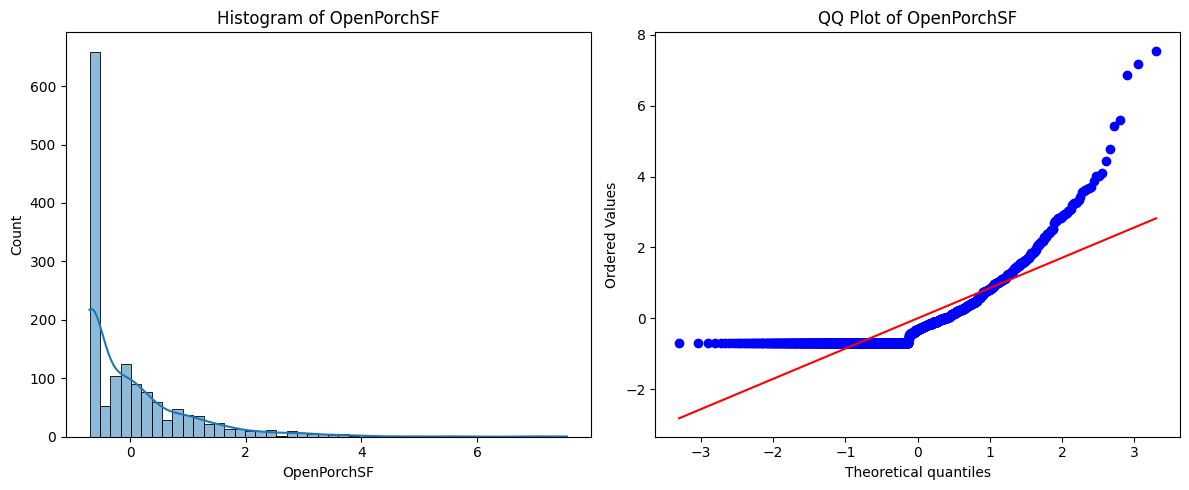

Column: EnclosedPorch
Shapiro-Wilk Statistic: 0.4146, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


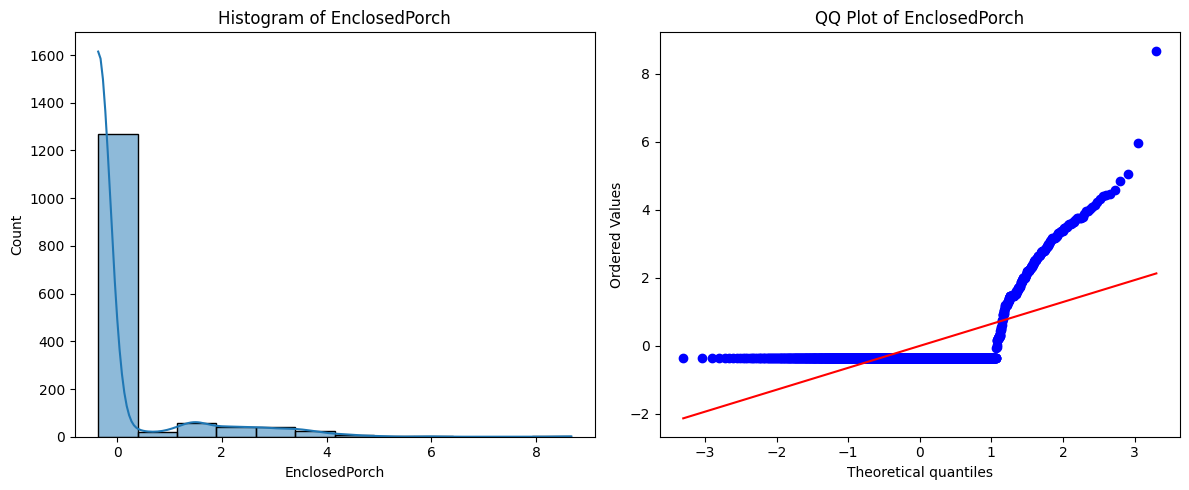

Column: 3SsnPorch
Shapiro-Wilk Statistic: 0.0950, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


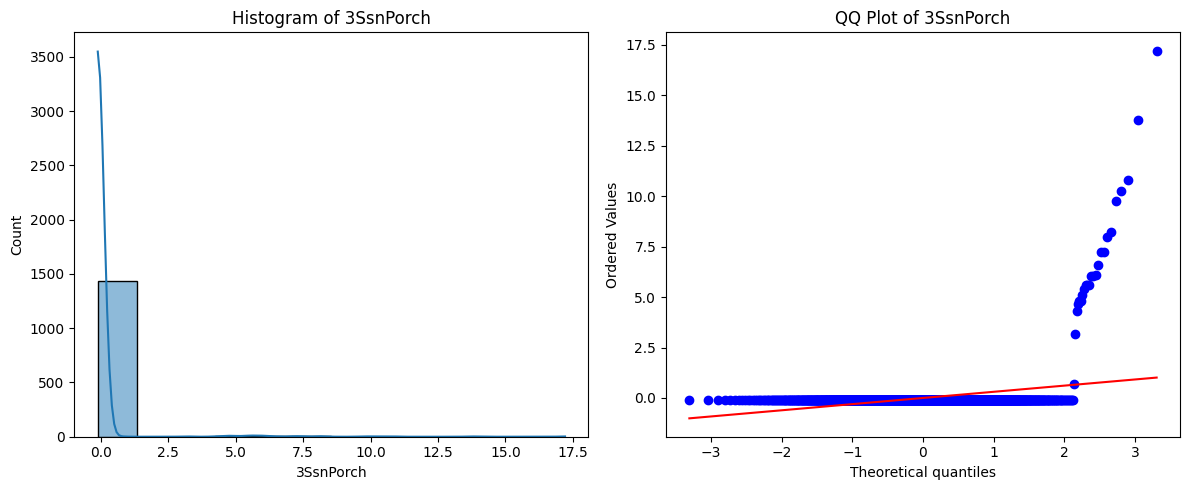

Column: ScreenPorch
Shapiro-Wilk Statistic: 0.2983, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


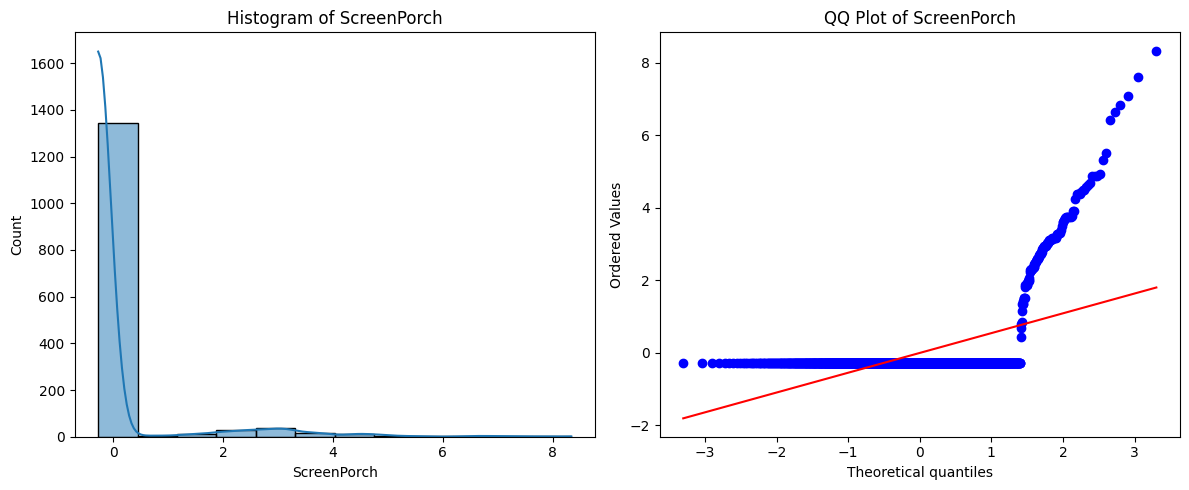

Column: PoolArea
Shapiro-Wilk Statistic: 0.0412, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


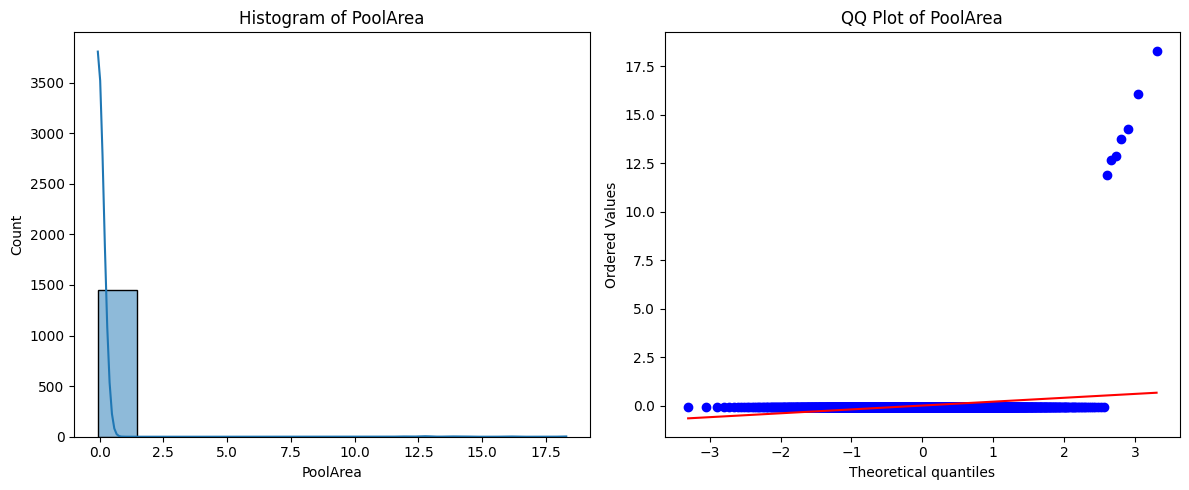

Column: MiscVal
Shapiro-Wilk Statistic: 0.0583, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


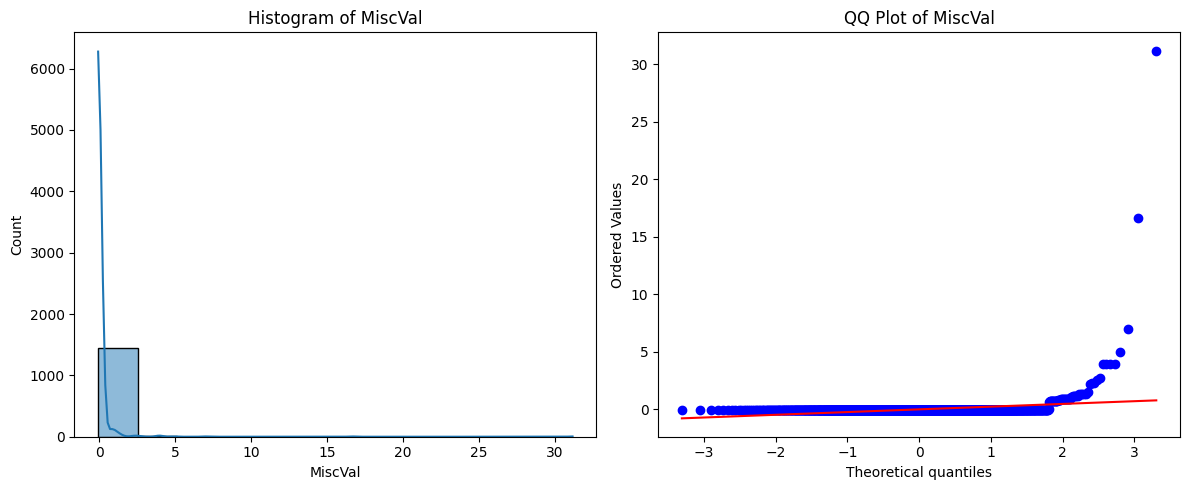

Column: MoSold
Shapiro-Wilk Statistic: 0.9688, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


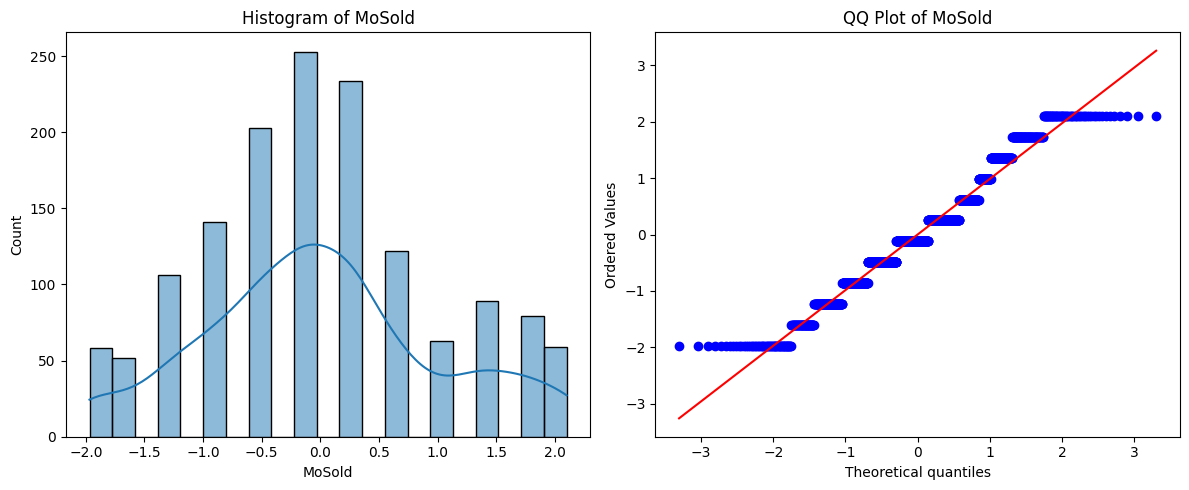

Column: YrSold
Shapiro-Wilk Statistic: 0.8970, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


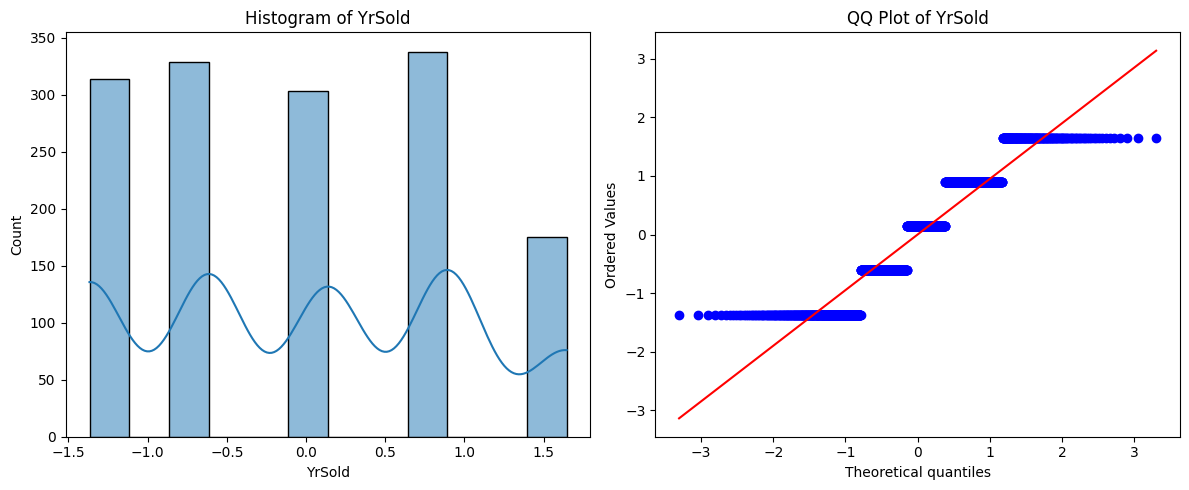

Column: SalePrice
Shapiro-Wilk Statistic: 0.8697, P-value: 0.0000
Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)
------------------------------


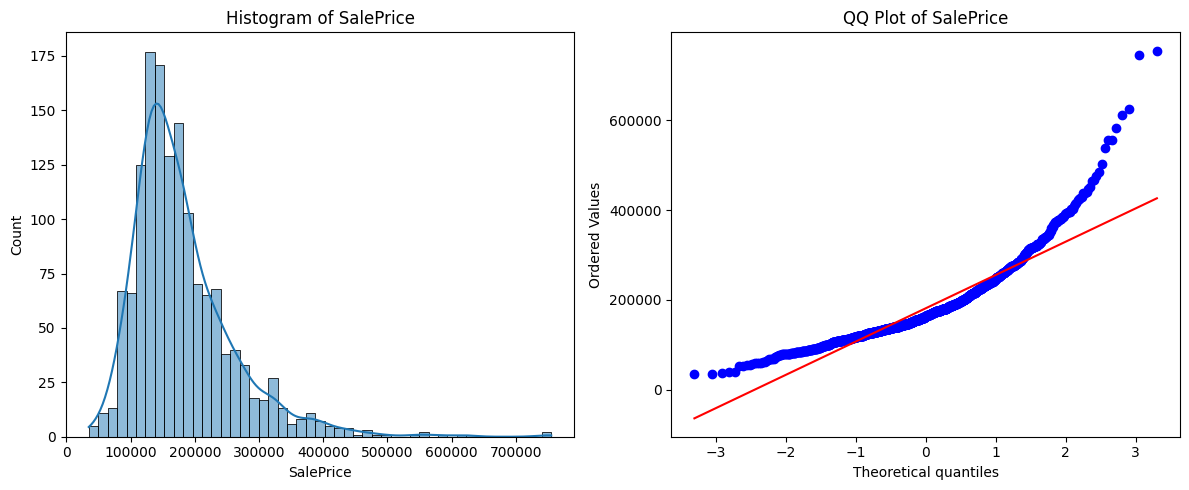

In [ ]:
# prompt: identify wheter the final_df dataset is normally distributed or not?

# Identify numerical columns
numerical_cols = final_df.select_dtypes(include=np.number).columns

# Check for normality for each numerical column
for col in numerical_cols:
    # Shapiro-Wilk test for normality
    # p-value < 0.05 suggests the data is NOT normally distributed
    stat, p_value = stats.shapiro(final_df[col])

    alpha = 0.05
    print(f"Column: {col}")
    print(f"Shapiro-Wilk Statistic: {stat:.4f}, P-value: {p_value:.4f}")

    if p_value > alpha:
        print("Conclusion: The data for this column appears to be normally distributed (fail to reject H0)")
    else:
        print("Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)")
    print("-" * 30)

    # Optional: Visualize the distribution using a histogram and QQ plot
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(final_df[col], kde=True)
    plt.title(f'Histogram of {col}')

    # QQ Plot
    plt.subplot(1, 2, 2)
    stats.probplot(final_df[col], dist="norm", plot=plt)
    plt.title(f'QQ Plot of {col}')

    plt.tight_layout()
    plt.show()

Number of outlier rows identified: 439
Shape after removing outliers: (1020, 175)

Outliers have been capped in the original dataframe.


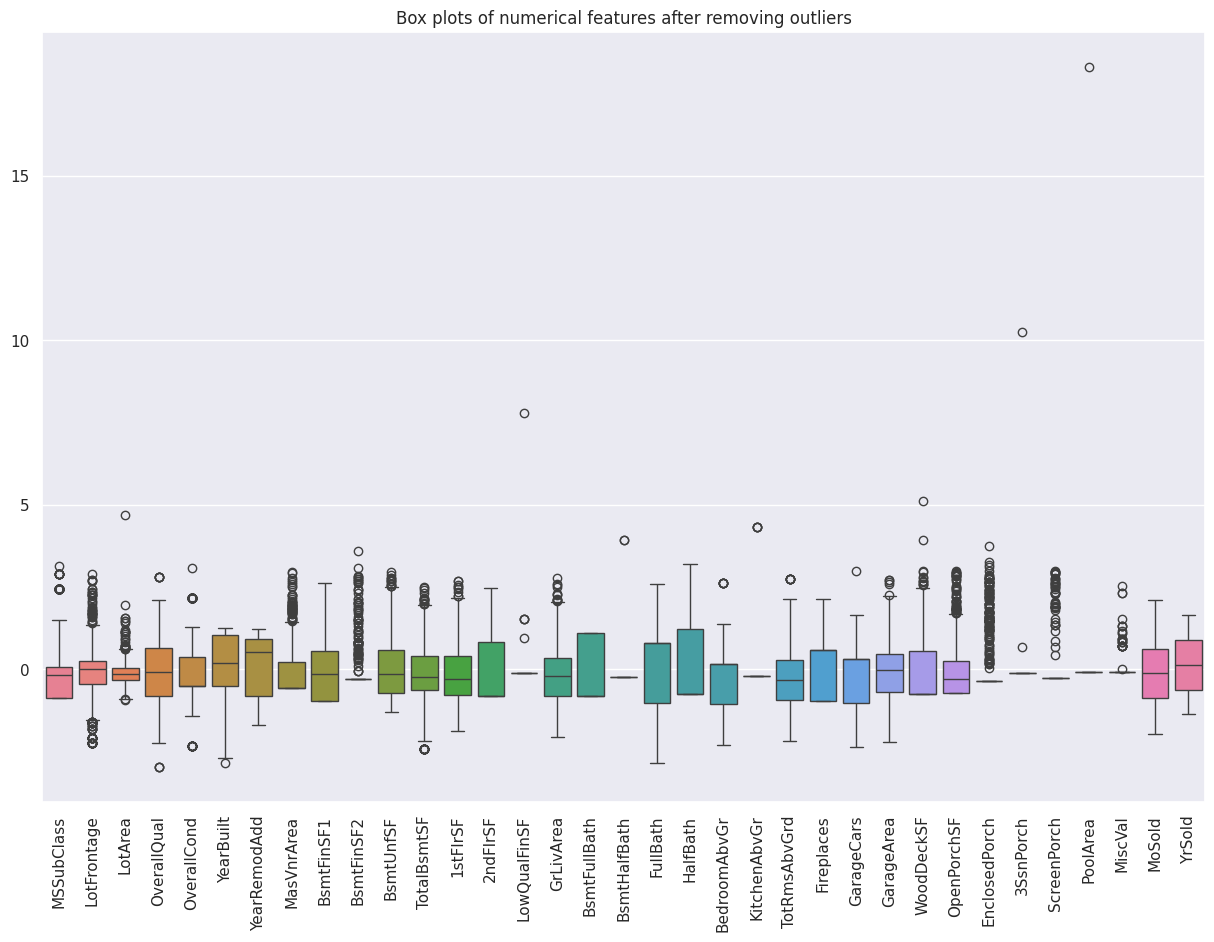

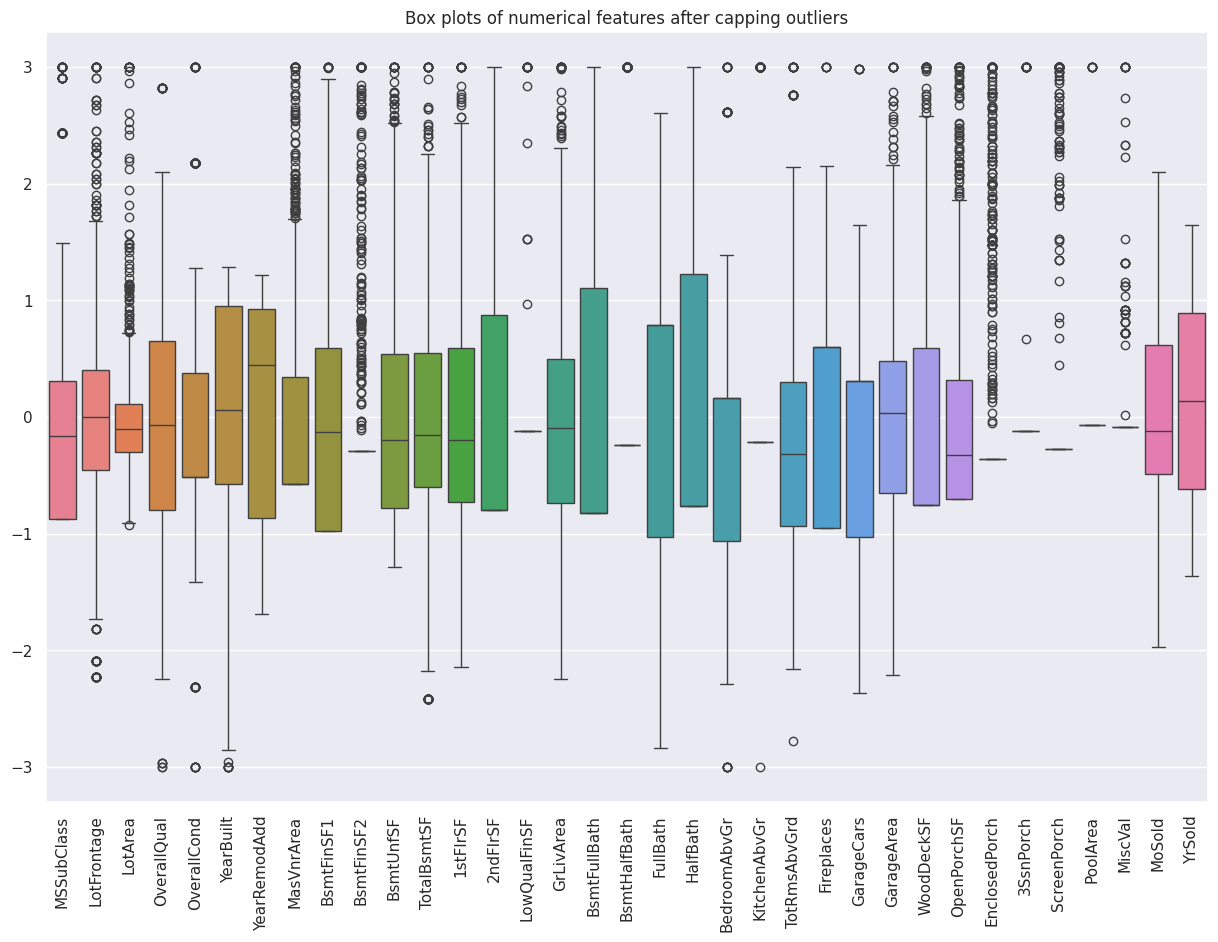

In [62]:
# Use Z-score to detect outliers in numerical features
z_scores = np.abs(stats.zscore(final_df[numerical_features]))
outlier_threshold = 3 # A common threshold

# Identify rows with outliers
outlier_rows = np.where(z_scores > outlier_threshold)[0]

print(f"Number of outlier rows identified: {len(np.unique(outlier_rows))}")

# Option 1: Remove outliers (simplest approach)
df_cleaned = final_df.drop(np.unique(outlier_rows)).reset_index(drop=True)
print(f"Shape after removing outliers: {df_cleaned.shape}")

# Option 2: Cap outliers (replace values beyond a certain threshold)
# we can cap values at the threshold or the mean/median
for col in numerical_features:
    upper_limit = final_df[col].mean() + outlier_threshold * final_df[col].std()
    lower_limit = final_df[col].mean() - outlier_threshold * final_df[col].std()
    final_df[col] = np.where(
        final_df[col] > upper_limit,
        upper_limit,
        np.where(
            final_df[col] < lower_limit,
            lower_limit,
            final_df[col]
        )
    )

print("\nOutliers have been capped in the original dataframe.")
# we can visualize the data before and after handling outliers to see the effect
# For example, using box plots for numerical features
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_cleaned[numerical_features])
plt.title('Box plots of numerical features after removing outliers')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(15, 10))
sns.boxplot(data=final_df[numerical_features])
plt.title('Box plots of numerical features after capping outliers')
plt.xticks(rotation=90)
plt.show()

### 2.1	Creating Interaction Features: Create meaningful interaction features that may help improve model performance

In [73]:
categorical_features1 = final_df.select_dtypes(include=[np.object_])
categorical_features

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [71]:
numerical_features1 = final_df.select_dtypes(include=[np.number])
numerical_features1.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [85]:
len(numerical_features1.columns)

36

In [74]:
correlation = numerical_features1.corr()
print(correlation['SalePrice'].sort_values(ascending=False), '\n')

SalePrice        1.000000
OverallQual      0.792018
GrLivArea        0.713548
TotalBsmtSF      0.644325
GarageCars       0.640473
GarageArea       0.629937
1stFlrSF         0.625010
FullBath         0.560881
TotRmsAbvGrd     0.537079
YearBuilt        0.523625
YearRemodAdd     0.507430
Fireplaces       0.468612
MasVnrArea       0.466814
BsmtFinSF1       0.400900
LotArea          0.384331
LotFrontage      0.360766
OpenPorchSF      0.343612
WoodDeckSF       0.328986
2ndFlrSF         0.312390
HalfBath         0.286420
BsmtFullBath     0.228441
BsmtUnfSF        0.210286
BedroomAbvGr     0.176234
ScreenPorch      0.103896
PoolArea         0.093701
3SsnPorch        0.047483
MoSold           0.046380
BsmtHalfBath    -0.015986
YrSold          -0.028907
BsmtFinSF2      -0.036801
MiscVal         -0.040880
LowQualFinSF    -0.046690
OverallCond     -0.080626
MSSubClass      -0.083059
KitchenAbvGr    -0.136606
EnclosedPorch   -0.147104
Name: SalePrice, dtype: float64 



In [86]:
correlation.shape

(36, 36)

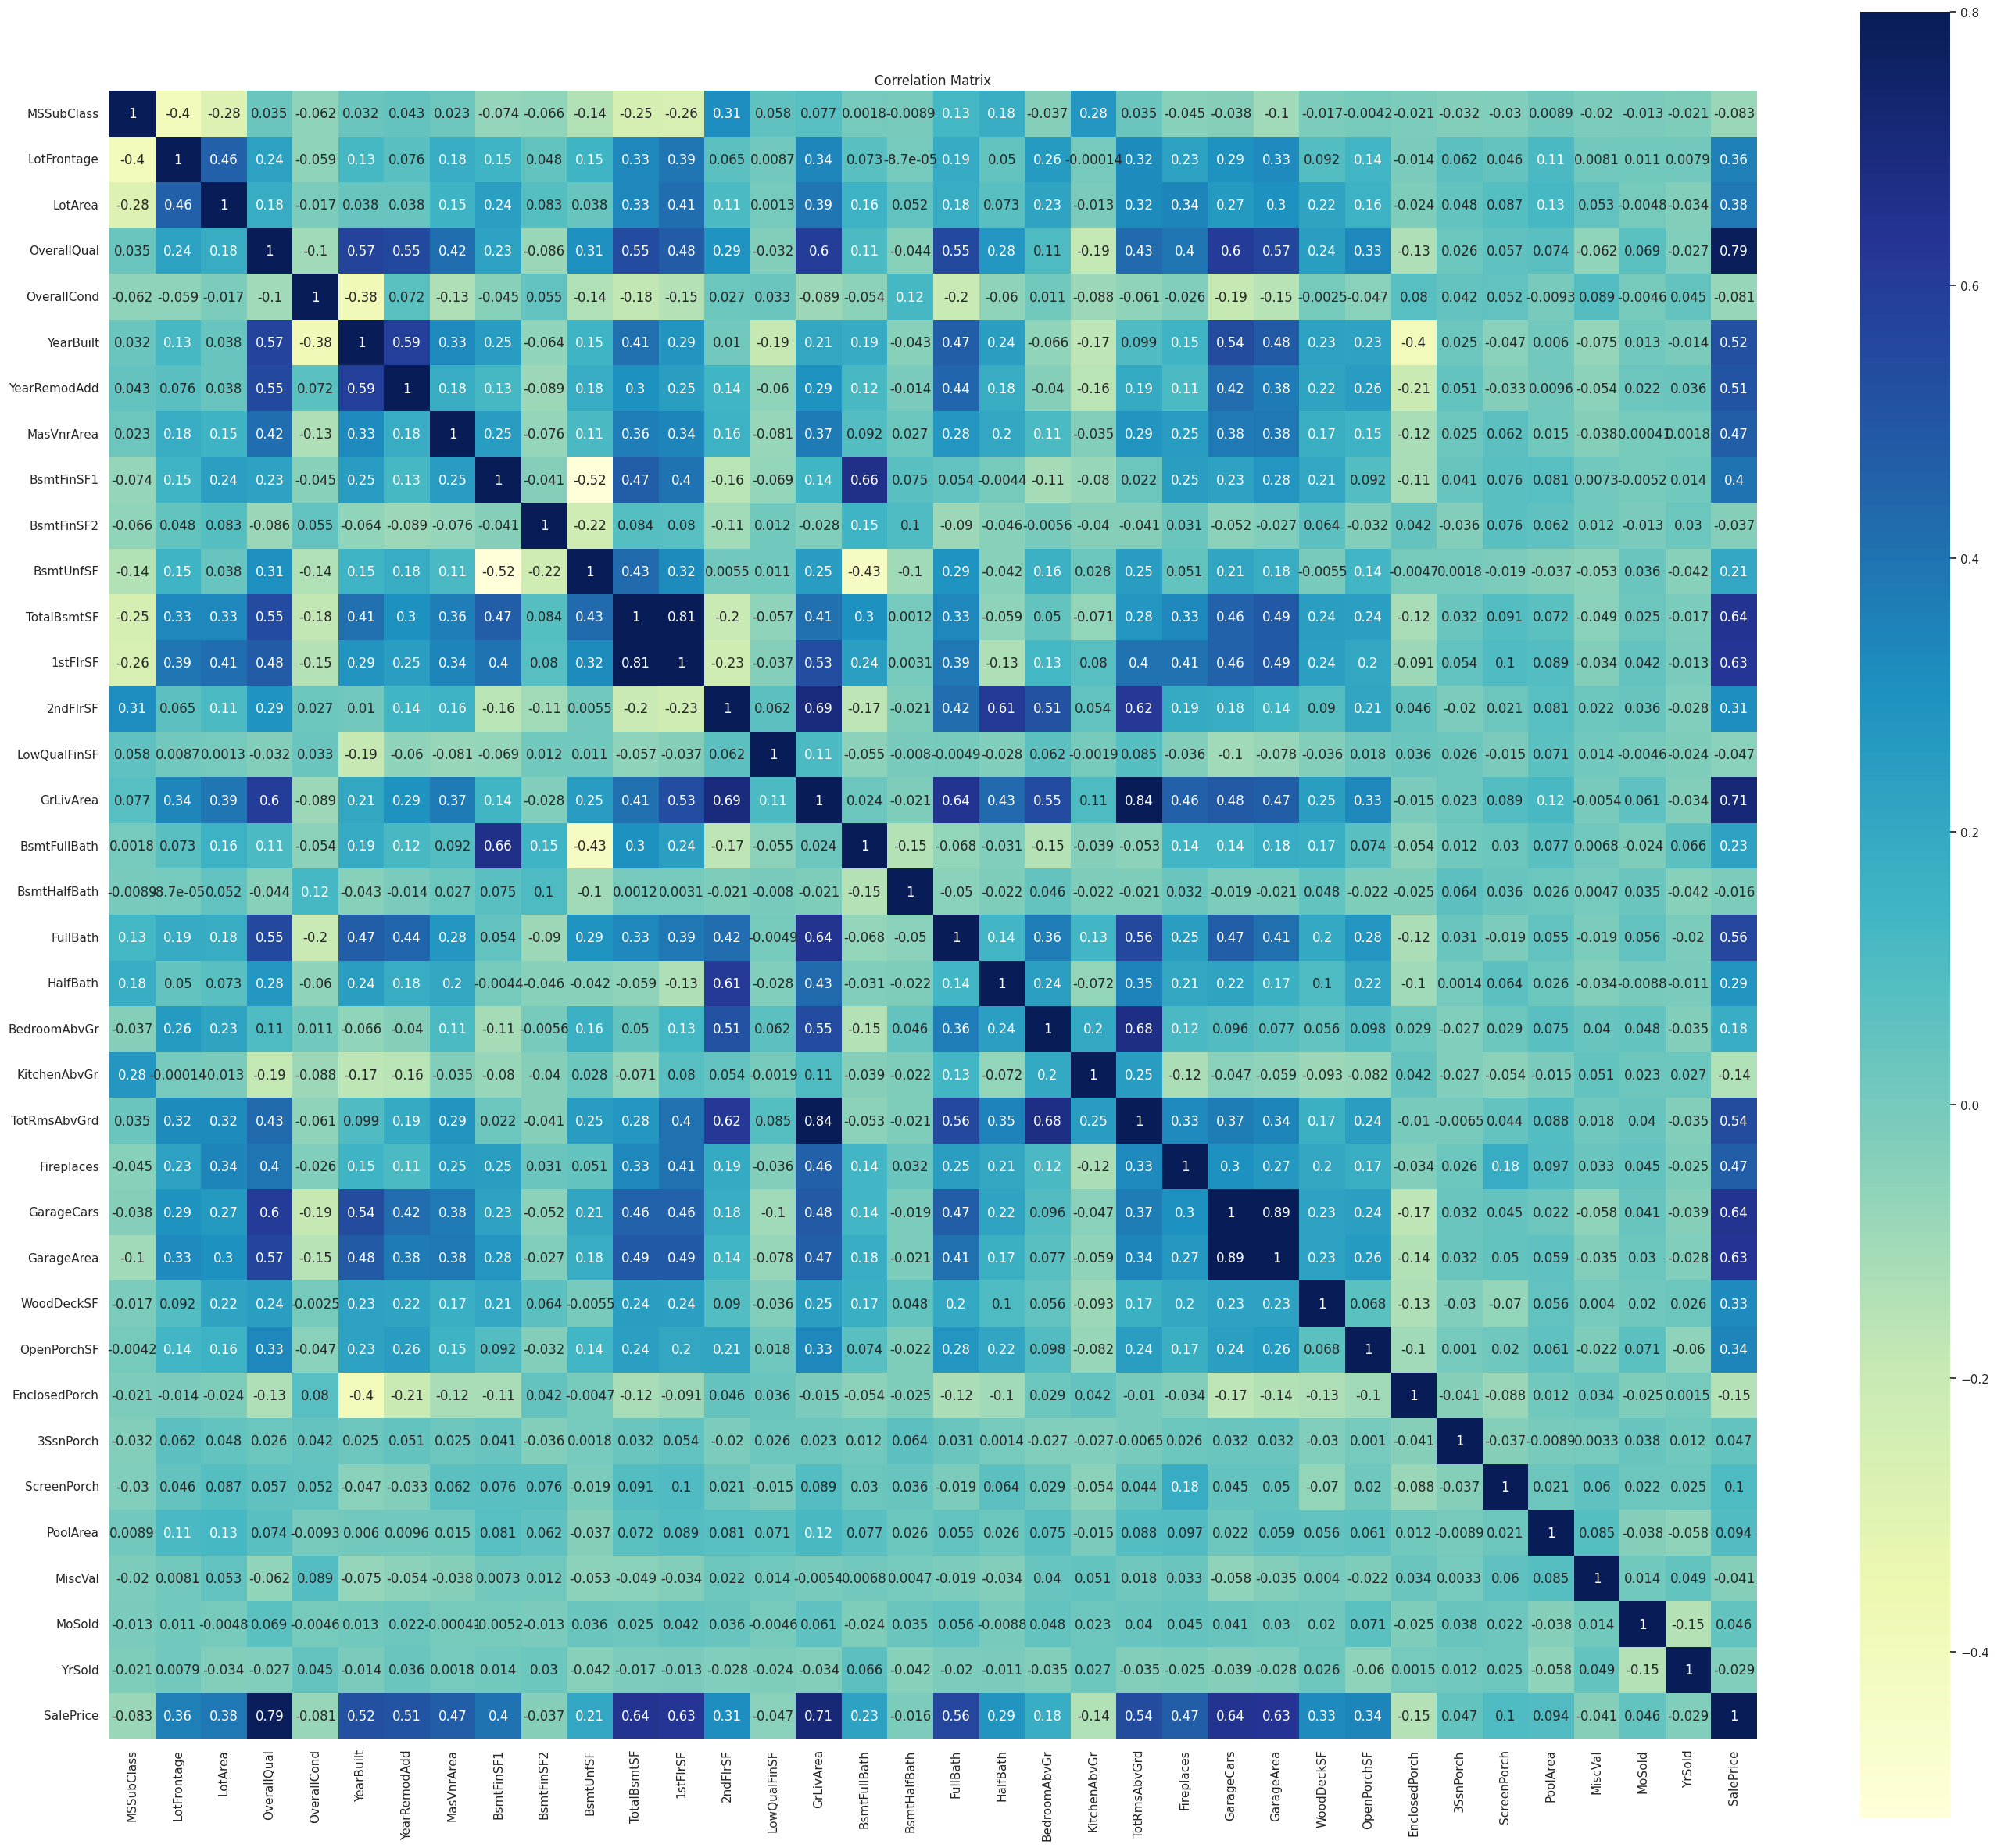

In [79]:
f, ax = plt.subplots(figsize=(34, 30))
plt.title('Correlation Matrix')
sns.heatmap(correlation, vmax=.8, square=True, cmap="YlGnBu", annot=True)
plt.show()

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars',
       'GarageArea', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt',
       'YearRemodAdd'],
      dtype='object')


<Axes: >

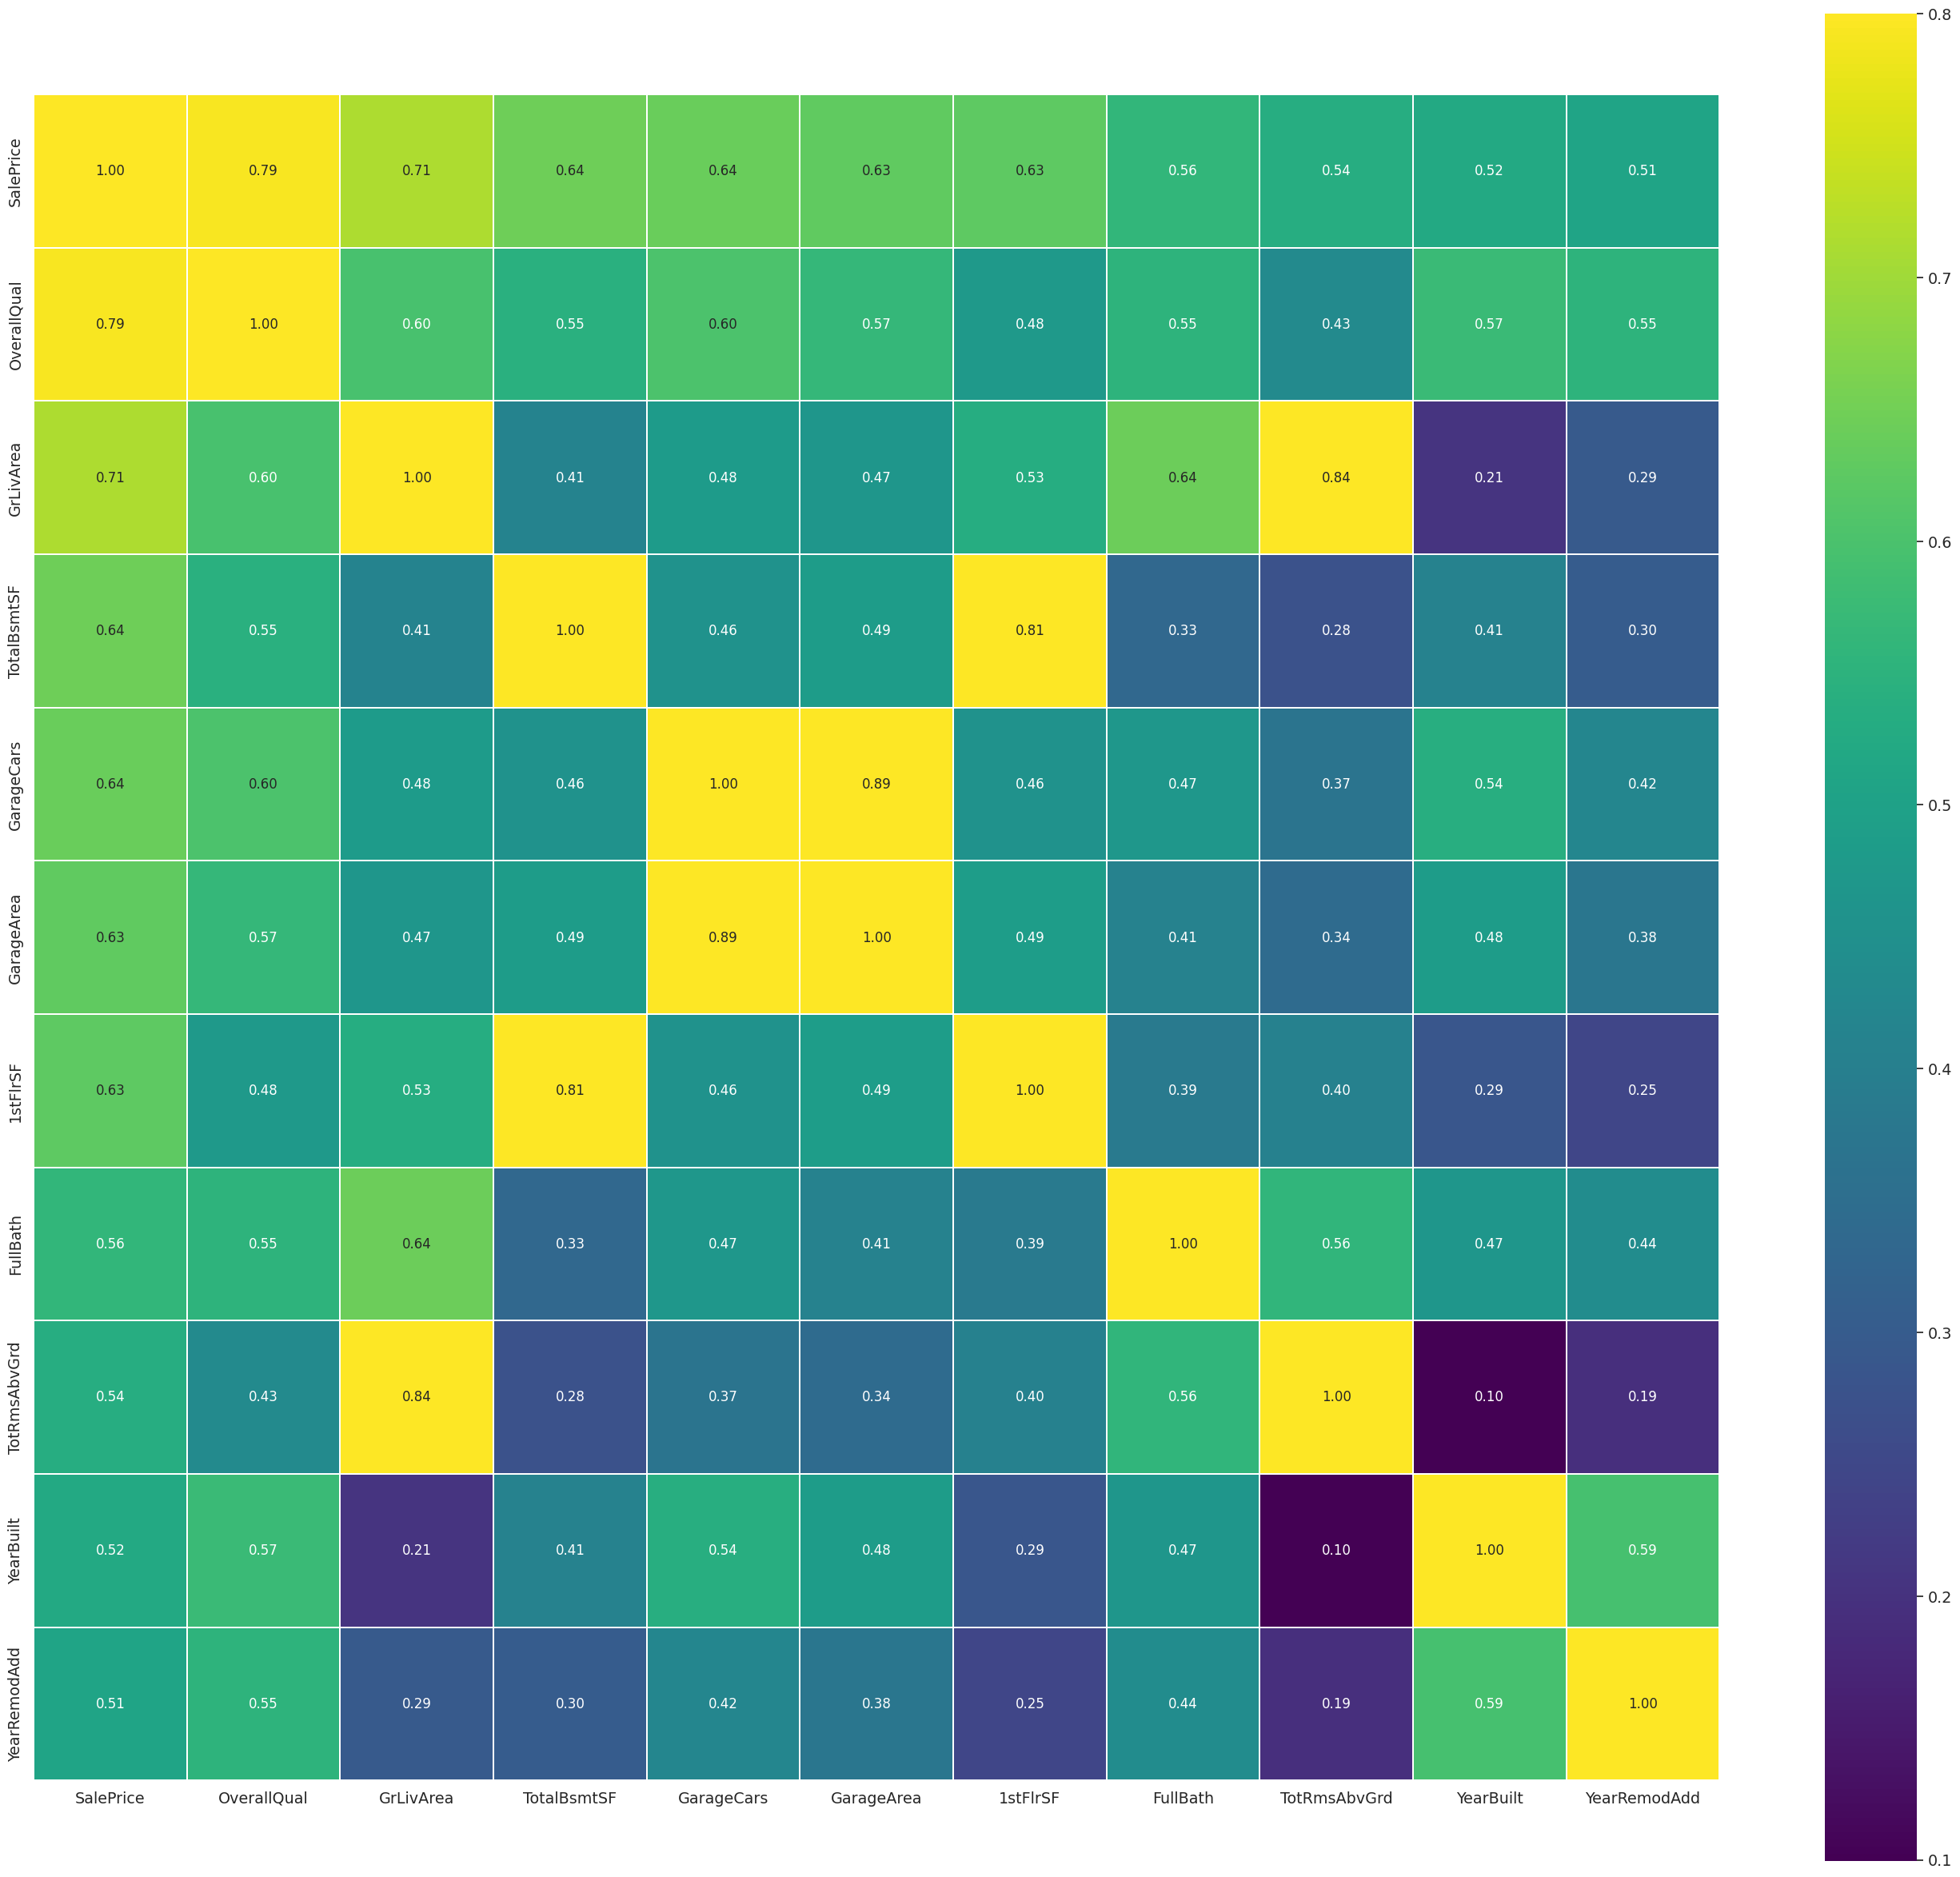

In [89]:
k = 11
cols = correlation.nlargest(k, 'SalePrice')['SalePrice'].index
print(cols)
cm = np.corrcoef(final_df[cols].values.T)
sns.set(font_scale=1.25)
f, ax = plt.subplots(figsize=(34, 30))
sns.heatmap(cm, vmax=0.8, linewidths=.01, cmap="viridis", linecolor='white', annot=True, square=True, fmt='.2f', annot_kws={'size': 12}, yticklabels=cols.values, xticklabels=cols.values)

In [92]:
# prompt: find multicollinear features between independent features from above correlation data

# Separate features (X) and target (y)
X = final_df.drop('SalePrice', axis=1)
y = final_df['SalePrice']

# Calculate the correlation matrix for independent variables
X_corr = X.corr()

# Set a threshold for multicollinearity (e.g., absolute correlation greater than 0.7)
multicollinearity_threshold = 0.7

# Find features that are highly correlated with each other
high_corr_pairs = {}
for i in range(len(X_corr.columns)):
    for j in range(i):
        if abs(X_corr.iloc[i, j]) > multicollinearity_threshold:
            colname_i = X_corr.columns[i]
            colname_j = X_corr.columns[j]
            high_corr_pairs[(colname_i, colname_j)] = X_corr.iloc[i, j]

# Print the highly correlated pairs
if high_corr_pairs:
    print("Highly multicollinear features (absolute correlation > {}):".format(multicollinearity_threshold))
    for pair, corr_value in high_corr_pairs.items():
        print(f"  {pair[0]} and {pair[1]}: {corr_value:.4f}")
else:
    print("No highly multicollinear features found above the threshold of {}.".format(multicollinearity_threshold))

# You might want to further investigate these pairs and decide which one(s) to keep
# (e.g., based on domain knowledge, VIF scores, or keeping the one with stronger correlation to the target)

Highly multicollinear features (absolute correlation > 0.7):
  1stFlrSF and TotalBsmtSF: 0.8072
  TotRmsAbvGrd and GrLivArea: 0.8381
  GarageArea and GarageCars: 0.8884
  RM and RL: -0.8086
  Somerst and FV: 0.8628
  Duplex and KitchenAbvGr: 0.7155
  1Story and 2ndFlrSF: -0.7911
  2Story and 2ndFlrSF: 0.8120
  Hip and Gable: -0.9335
  CmentBd and CemntBd: 0.9742
  TA and Gd: -0.9061
  GasW and GasA: -0.7463
  Detchd and Attchd: -0.8221
  WD and New: -0.7737
  Partial and New: 0.9868
  Partial and WD: -0.7695


In [91]:
# prompt: list poor correlation with target features from above correlation data

# List features with poor correlation with 'SalePrice'
correlation_with_target = correlation['SalePrice'].sort_values()

# Set a threshold for poor correlation (e.g., absolute correlation less than 0.1 or 0.2)
poor_correlation_threshold = 0.2

poorly_correlated_features = correlation_with_target[abs(correlation_with_target) < poor_correlation_threshold]

print(f"\nFeatures with poor correlation (absolute correlation < {poor_correlation_threshold}) with 'SalePrice':")
poorly_correlated_features


Features with poor correlation (absolute correlation < 0.2) with 'SalePrice':


,SalePrice
EnclosedPorch,-0.147104
KitchenAbvGr,-0.136606
MSSubClass,-0.083059
OverallCond,-0.080626
LowQualFinSF,-0.046690
MiscVal,-0.040880
BsmtFinSF2,-0.036801
YrSold,-0.028907
BsmtHalfBath,-0.015986
MoSold,0.046380
